# 🌞 Güneş Paneli Arıza Tespiti — Derin Öğrenme Projesi

**Veri Seti:** SPHERE — Solar Panel Hidden Defect Evaluation for Renewable Energy  
**Kaggle:** [kubilayayturan/sphere-solar-panel-hidden-defect-evaluation-for-re](https://www.kaggle.com/datasets/kubilayayturan/sphere-solar-panel-hidden-defect-evaluation-for-re/data)  
**Referans Makale:** Ayturan et al. (2025), Applied Sciences, 15(9), 4880 — [Link](https://www.mdpi.com/2076-3417/15/9/4880)

**Sınıflar (3 adet):**
- `broken` (kırık) → label 0
- `clean` (temiz) → label 1
- `dirty` (kirli) → label 2

**4 Derin Öğrenme Mimarisi:**
1. Özel CNN (sıfırdan tasarlanmış)
2. EfficientNetB0 (transfer learning)
3. MobileNetV3Large (transfer learning)
4. ConvNeXt-Tiny (transfer learning)

---

## 1. Kurulum & Import

In [1]:
!pip install -q tf-keras-vis

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import (
    EfficientNetB0,
    MobileNetV3Large,
    ConvNeXtTiny
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# Tekrarlanabilirlik için seed sabitleme
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Daha önce eğitilmiş modelleri yükle (varsa)
import os
# =============================================================
# Kaggle ortamı — çıktılar /kaggle/working/ altına kaydedilir
# =============================================================
import os

OUTPUT_DIR = '/kaggle/working'
MODELS_DIR = os.path.join(OUTPUT_DIR, 'saved_models')
os.makedirs(MODELS_DIR, exist_ok=True)

print(f"Çıktı dizini: {OUTPUT_DIR}")
print(f"Model kayıt dizini: {MODELS_DIR}")

# GPU kontrolü
print(f"\nGPU: {tf.config.list_physical_devices('GPU')}")

# GPU kontrolü
print("TensorFlow sürümü:", tf.__version__)
print("GPU kullanılabilir mi:", tf.config.list_physical_devices('GPU'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 2.0 MB/s eta 0:00:00


2026-04-30 19:20:57.701722: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777576857.907121      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777576857.967586      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777576858.469648      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777576858.469703      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777576858.469706      57 computation_placer.cc:177] computation placer alr

Çıktı dizini: /kaggle/working
Model kayıt dizini: /kaggle/working/saved_models

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
TensorFlow sürümü: 2.19.0
GPU kullanılabilir mi: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Veri Yükleme 

In [2]:
# =============================================================
# 2. Veri Yükleme — Kaggle Notebook
# =============================================================

# Kaggle'da çıktıların kaydedileceği çalışma klasörü
DRIVE_PROJECT_DIR = '/kaggle/working/SPHERE_Proje'
DATA_DIR = None
ZIP_FILENAME = 'sphere-solar-panel-hidden-defect-evaluation-for-re.zip'
ZIP_PATH = os.path.join(DRIVE_PROJECT_DIR, ZIP_FILENAME)

os.makedirs(DRIVE_PROJECT_DIR, exist_ok=True)

# Kaggle input altında sadece gerekli klasörü bul:
# .../CNN_Data_Arranged/320p/{broken, clean, dirty}
def find_dataset_path(base_dir='/kaggle/input'):
    for root, dirs, files in os.walk(base_dir):
        dir_names = {d.lower() for d in dirs}
        if os.path.basename(root).lower() == '320p' and {'broken', 'clean', 'dirty'}.issubset(dir_names):
            return root
    raise FileNotFoundError(
        "320p altında broken/clean/dirty klasörleri bulunamadı. "
        "Dataset'i Kaggle notebook'a eklediğinden emin ol."
    )

# Artık zip indirme/açma yok; doğrudan Kaggle input'taki gerekli klasörü kullan
DATA_DIR = find_dataset_path()

print(f"\nKullanılacak veri dizini: {DATA_DIR}")

# Dizin yapısını kontrol et
print(f"\n{'='*50}")
for root, dirs, file_list in os.walk(DATA_DIR):
    level = root.replace(DATA_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 1:
        subindent = ' ' * 2 * (level + 1)
        for d in dirs:
            print(f'{subindent}{d}/')
        if file_list:
            print(f'{subindent}({len(file_list)} dosya)')

!du -sh "{DATA_DIR}"

# Gerçek görüntü dizinini bul
CNN_DATA_PATH = None
for root, dirs, files in os.walk(DATA_DIR):
    if '320p' in dirs:
        CNN_DATA_PATH = os.path.join(root, '320p')
        break
    # Doğrudan broken/clean/dirty varsa
    if {'broken', 'clean', 'dirty'}.issubset({d.lower() for d in dirs}):
        CNN_DATA_PATH = root
        break

print(f"CNN görüntü dizini: {CNN_DATA_PATH}")
print(f"Sınıflar: {os.listdir(CNN_DATA_PATH)}")

# Görüntü sayısını kontrol et
for cls in ['broken', 'clean', 'dirty']:
    cls_path = os.path.join(CNN_DATA_PATH, cls)
    if os.path.exists(cls_path):
        count = len([f for f in os.listdir(cls_path) if not f.startswith('.')])
        print(f"  {cls}: {count} görüntü")

# Kaggle'da kopyalama/silme yapmadan doğrudan bu dizini kullan
DATASET_PATH = CNN_DATA_PATH
print(f"\nTemiz veri seti dizini: {DATASET_PATH}")
print(f"Sınıflar: {os.listdir(DATASET_PATH)}")
!du -sh "{DATASET_PATH}"

CNN_DATA_PATH = DATA_DIR
DATASET_PATH = DATA_DIR


Kullanılacak veri dizini: /kaggle/input/datasets/kubilayayturan/sphere-solar-panel-hidden-defect-evaluation-for-re/SPHERE DATASET/SPHERE DATASET/SPHERE - LABELLED DATASET/CNN_Data_Arranged/320p

320p/
  broken/
  clean/
  dirty/
  broken/
  clean/
  dirty/
433M	/kaggle/input/datasets/kubilayayturan/sphere-solar-panel-hidden-defect-evaluation-for-re/SPHERE DATASET/SPHERE DATASET/SPHERE - LABELLED DATASET/CNN_Data_Arranged/320p
CNN görüntü dizini: /kaggle/input/datasets/kubilayayturan/sphere-solar-panel-hidden-defect-evaluation-for-re/SPHERE DATASET/SPHERE DATASET/SPHERE - LABELLED DATASET/CNN_Data_Arranged/320p
Sınıflar: ['broken', 'clean', 'dirty']
  broken: 1704 görüntü
  clean: 2130 görüntü
  dirty: 2245 görüntü

Temiz veri seti dizini: /kaggle/input/datasets/kubilayayturan/sphere-solar-panel-hidden-defect-evaluation-for-re/SPHERE DATASET/SPHERE DATASET/SPHERE - LABELLED DATASET/CNN_Data_Arranged/320p
Sınıflar: ['broken', 'clean', 'dirty']
433M	/kaggle/input/datasets/kubilayayturan/

In [3]:
# Tüm görüntü yollarını ve etiketlerini topla
CLASS_NAMES = ['broken', 'clean', 'dirty']  # Sıralama: 0=broken, 1=clean, 2=dirty
IMG_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

image_paths = []
labels = []

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(DATASET_PATH, class_name)
    if not os.path.exists(class_dir):
        # Büyük harfli versiyonu dene
        class_dir = os.path.join(DATASET_PATH, class_name.capitalize())
    if not os.path.exists(class_dir):
        print(f"UYARI: {class_name} dizini bulunamadı!")
        continue

    files = [f for f in os.listdir(class_dir)
             if os.path.splitext(f)[1].lower() in IMG_EXTENSIONS]
    for f in files:
        image_paths.append(os.path.join(class_dir, f))
        labels.append(class_idx)

print(f"Toplam görüntü sayısı: {len(image_paths)}")
print(f"Sınıf dağılımı: {Counter(labels)}")
print(f"Sınıf isimleri: {CLASS_NAMES}")

Toplam görüntü sayısı: 6079
Sınıf dağılımı: Counter({2: 2245, 1: 2130, 0: 1704})
Sınıf isimleri: ['broken', 'clean', 'dirty']


## 3. Keşifsel Veri Analizi (EDA)

EDA sonuçlarına göre veri seti orta düzeyde dengeli bir sınıf dağılımına sahiptir. En düşük örnek sayısı broken sınıfında, en yüksek örnek sayısı dirty sınıfındadır. Örnek görüntüler incelendiğinde broken sınıfında lokal yapısal bozulmalar, dirty sınıfında yüzeye yayılmış kirlilik örüntüleri, clean sınıfında ise daha homojen ve düzenli panel yapısı gözlemlenmektedir. Piksel yoğunluk histogramlarının büyük ölçüde örtüşmesi, sınıflandırma probleminin yalnızca parlaklık tabanlı değil, aynı zamanda doku ve mekânsal örüntü tabanlı olduğunu göstermektedir.

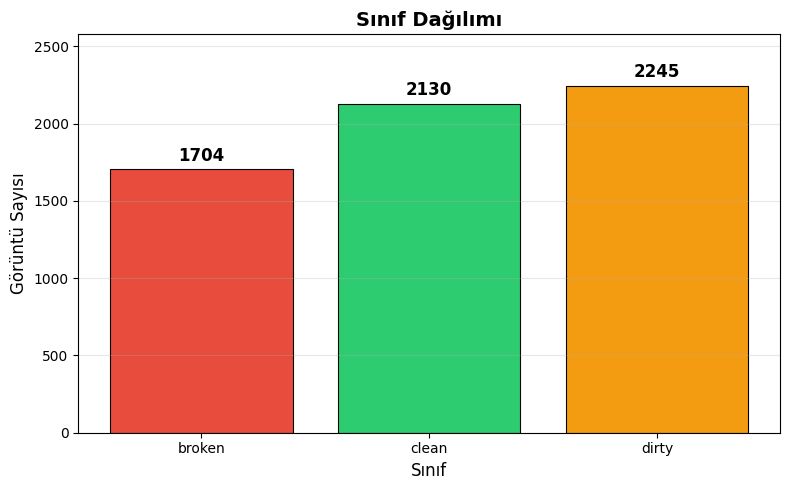


Sınıf Oranları:
  broken: 1704 (28.0%)
  clean: 2130 (35.0%)
  dirty: 2245 (36.9%)


In [4]:
# Sınıf dağılımı bar chart
class_counts = Counter(labels)
counts = [class_counts[i] for i in range(len(CLASS_NAMES))]

plt.figure(figsize=(8, 5))
colors = ['#e74c3c', '#2ecc71', '#f39c12']
bars = plt.bar(CLASS_NAMES, counts, color=colors, edgecolor='black', linewidth=0.8)

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 30,
             f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Sınıf Dağılımı', fontsize=14, fontweight='bold')
plt.xlabel('Sınıf', fontsize=12)
plt.ylabel('Görüntü Sayısı', fontsize=12)
plt.ylim(0, max(counts) * 1.15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

total = sum(counts)
print("\nSınıf Oranları:")
for name, count in zip(CLASS_NAMES, counts):
    print(f"  {name}: {count} ({count/total*100:.1f}%)")

### 1) Sınıf dağılımı

Veri seti tamamen dengeli değil ama ciddi dengesiz de değil. En az örnek broken, en fazla örnek dirty sınıfında. Bu şunu gösterir:

* **dirty** sınıfı model tarafından biraz daha kolay öğrenilebilir çünkü örnek sayısı fazla.
* **broken** sınıfı en az sayıda olduğu için burada recall düşme riski daha yüksek.
* Ancak fark çok uç olmadığı için veri seti hâlâ öğrenilebilir ve makul derecede dengeli kabul edilebilir.

Bu nedenle eğitim ve testte yalnızca accuracy değil, özellikle:

*   sınıf bazlı recall,
*   F1-score,
*   confusion matrix

çok önemli olacak.

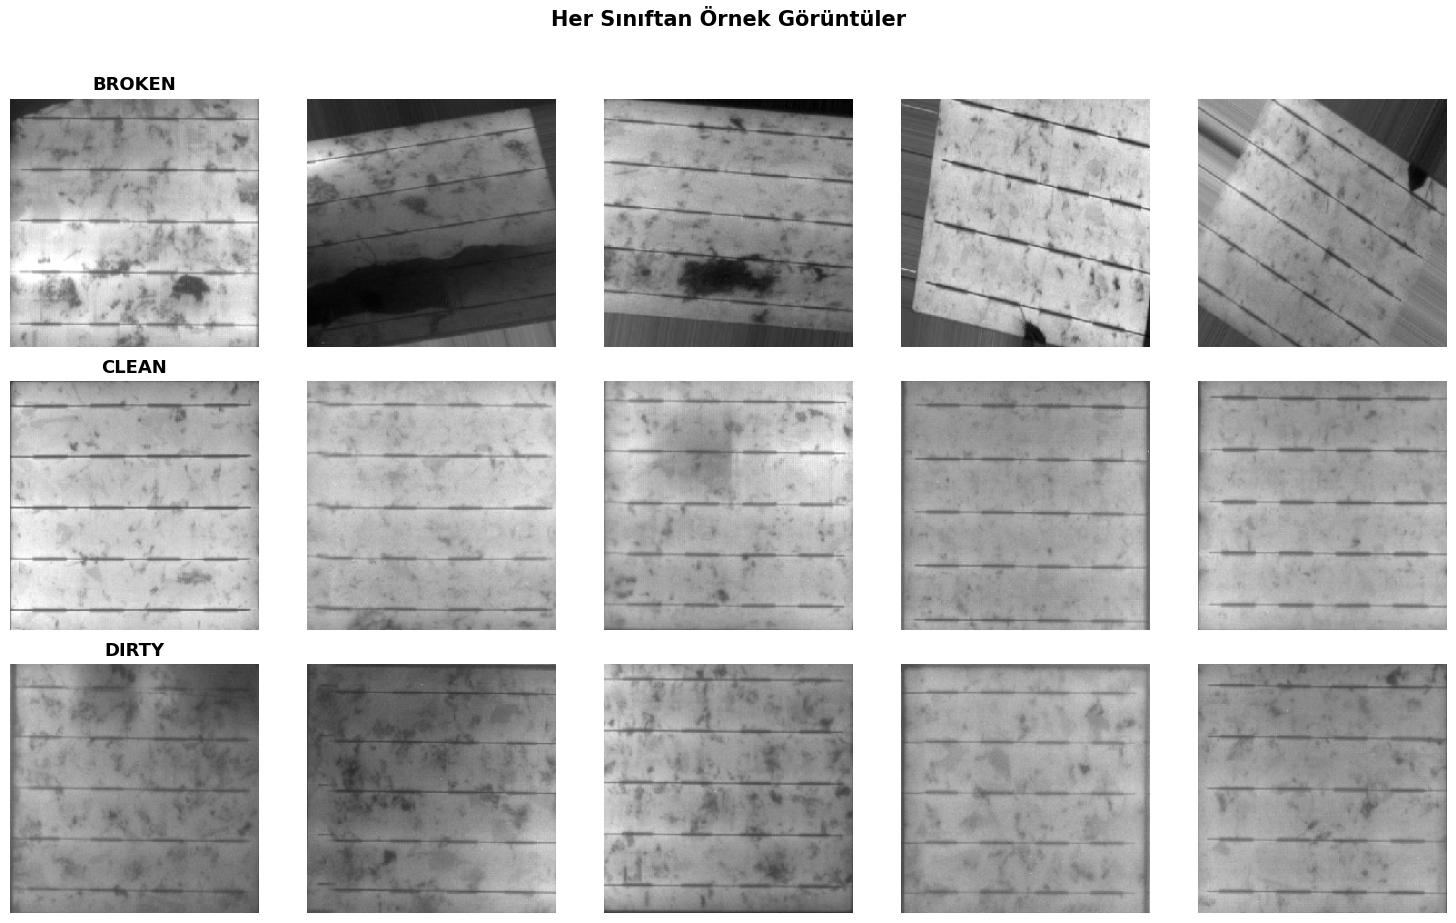

In [5]:
# Her sınıftan 5 örnek görüntü göster
from tensorflow.keras.preprocessing.image import load_img

fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for row_idx, class_name in enumerate(CLASS_NAMES):
    # Bu sınıfa ait görüntüleri filtrele
    class_images = [p for p, l in zip(image_paths, labels) if l == row_idx]
    sample_images = random.sample(class_images, min(5, len(class_images)))

    for col_idx, img_path in enumerate(sample_images):
        img = load_img(img_path, target_size=(224, 224))
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis('off')
        if col_idx == 0:
            axes[row_idx, col_idx].set_title(f'{class_name.upper()}',
                                              fontsize=13, fontweight='bold')

plt.suptitle('Her Sınıftan Örnek Görüntüler', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**broken**

* eğik panel görüntüleri daha fazla dikkat çekiyor,
* bazı örneklerde lokal koyu alanlar, çatlak/kırık benzeri belirgin bozulmalar var,
* yapısal anomali daha baskın.

Yani model burada daha çok lokal hasar ve düzensiz bozulmayı öğrenmeli.

**clean**

* panel çizgileri daha düzenli,
* görünüm daha homojen,
* koyu lekeler ve anormal bölgeler daha az.

Bu sınıf normal referans görünümü temsil ediyor.

**dirty**

* yüzeye yayılmış lekelenme ve kir desenleri var,
* broken’daki gibi tek bir keskin hasar yerine daha dağınık bozulmalar görülüyor,
* genel yüzey dokusu daha kirli ve heterojen.

Yani:

broken = lokal/yapısal bozulma

dirty = yaygın yüzey kirliliği

clean = daha homojen yapı

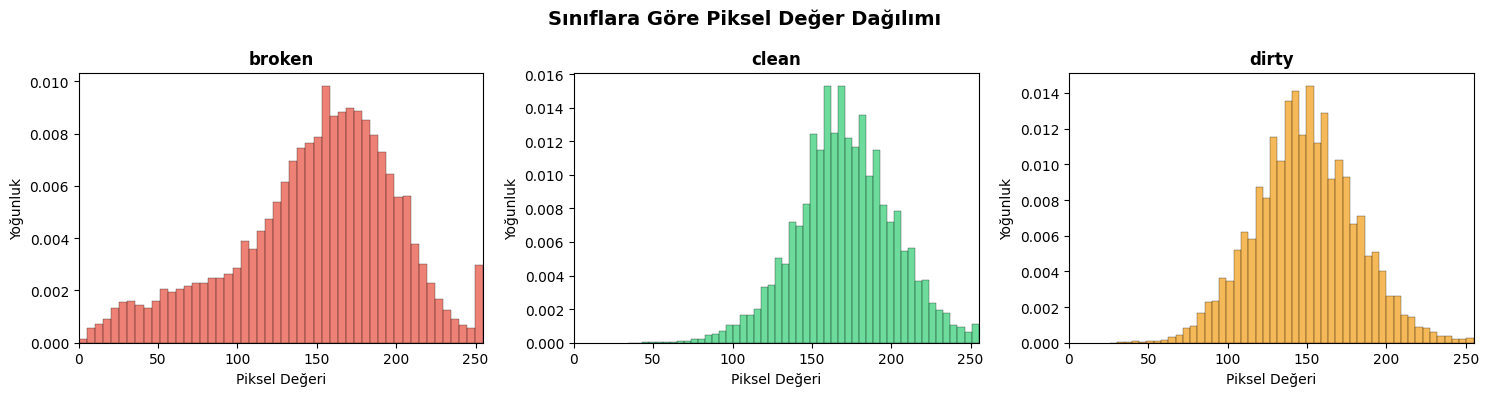

In [6]:
# Piksel değer dağılımı analizi
# Her sınıftan 50 örnek üzerinden ortalama piksel dağılımı
from tensorflow.keras.preprocessing.image import img_to_array

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_images = [p for p, l in zip(image_paths, labels) if l == class_idx]
    sample = random.sample(class_images, min(50, len(class_images)))

    all_pixels = []
    for img_path in sample:
        img = load_img(img_path, target_size=(224, 224))
        arr = img_to_array(img).flatten()
        all_pixels.extend(arr)

    axes[class_idx].hist(all_pixels, bins=50, color=colors[class_idx],
                         alpha=0.7, density=True, edgecolor='black', linewidth=0.3)
    axes[class_idx].set_title(f'{class_name}', fontsize=12, fontweight='bold')
    axes[class_idx].set_xlabel('Piksel Değeri')
    axes[class_idx].set_ylabel('Yoğunluk')
    axes[class_idx].set_xlim(0, 255)

plt.suptitle('Sınıflara Göre Piksel Değer Dağılımı', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Piksel dağılımlarına göre sınıflar arasında farklar var ama dağılımlar ciddi biçimde örtüşüyor. Bu şu anlama gelir:

* Problem yalnızca parlaklık farkı ile çözülemez.
* Modelin doku, mekânsal yapı ve lokal bozulma desenlerini öğrenmesi gerekir.
* Bu da CNN ve transfer learning kullanımını destekler.

* **broken:** daha düşük piksel tarafına uzanan koyu bölgeler lokal hasarla ilişkili olabilir.
* **clean:** daha düzenli ve merkezi dağılım beklenir.
* **dirty:** kir kaynaklı yaygın ton değişimleri nedeniyle orta yoğunluklarda geniş yayılım gösterebilir.

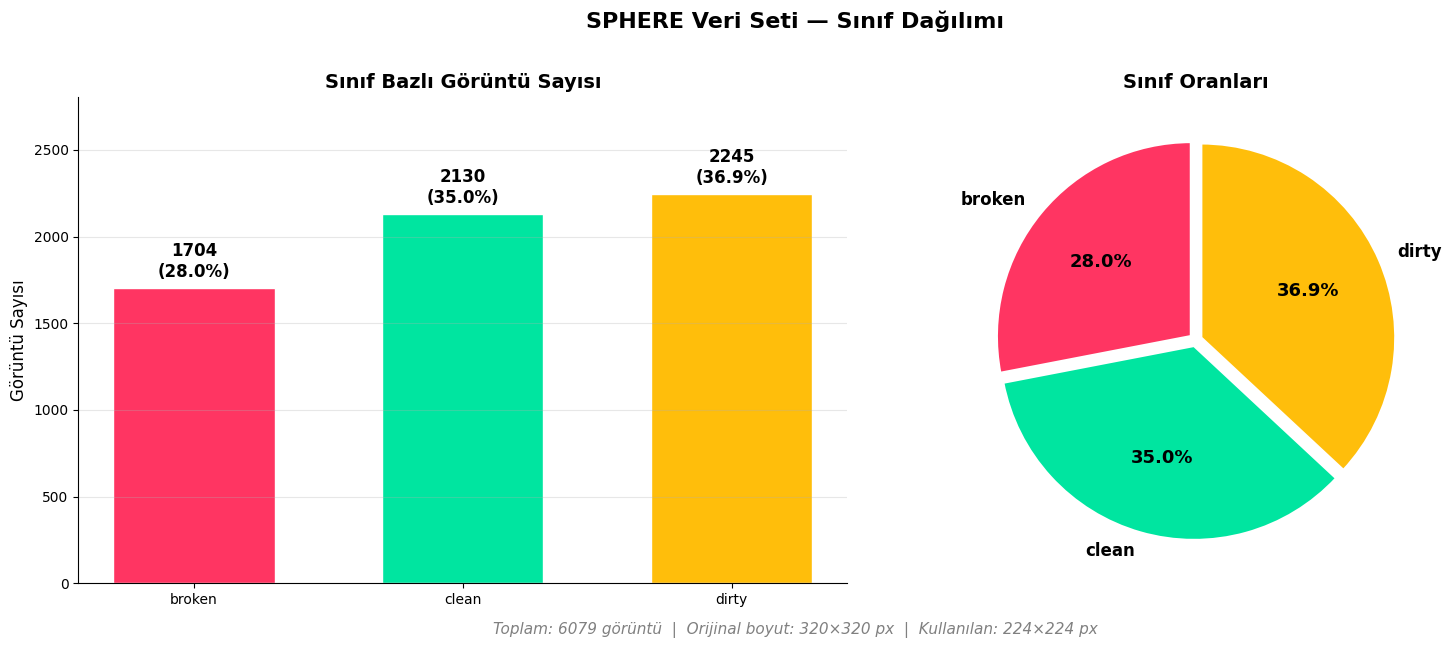

In [7]:
# =============================================================
# EDA 1: Sınıf Dağılımı — Pie + Bar Combo
# =============================================================

class_counts = Counter(labels)
counts = [class_counts[i] for i in range(len(CLASS_NAMES))]
total = sum(counts)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar Chart
colors = ['#FF3562', '#00E5A0', '#FFBE0B']
bars = ax1.bar(CLASS_NAMES, counts, color=colors, edgecolor='white', width=0.6)

for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 40,
             f'{count}\n({count/total*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=12)

ax1.set_title('Sınıf Bazlı Görüntü Sayısı', fontsize=14, fontweight='bold')
ax1.set_ylabel('Görüntü Sayısı', fontsize=12)
ax1.set_ylim(0, max(counts) * 1.25)
ax1.grid(axis='y', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Pie Chart
explode = (0.03, 0.03, 0.03)
wedges, texts, autotexts = ax2.pie(
    counts, labels=CLASS_NAMES, colors=colors,
    autopct='%1.1f%%', startangle=90, explode=explode,
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for t in autotexts:
    t.set_fontsize(13)
    t.set_fontweight('bold')

ax2.set_title('Sınıf Oranları', fontsize=14, fontweight='bold')

# Toplam bilgisi
fig.text(0.5, -0.02, f'Toplam: {total} görüntü  |  Orijinal boyut: 320×320 px  |  Kullanılan: 224×224 px',
         ha='center', fontsize=11, style='italic', color='gray')

plt.suptitle('SPHERE Veri Seti — Sınıf Dağılımı', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

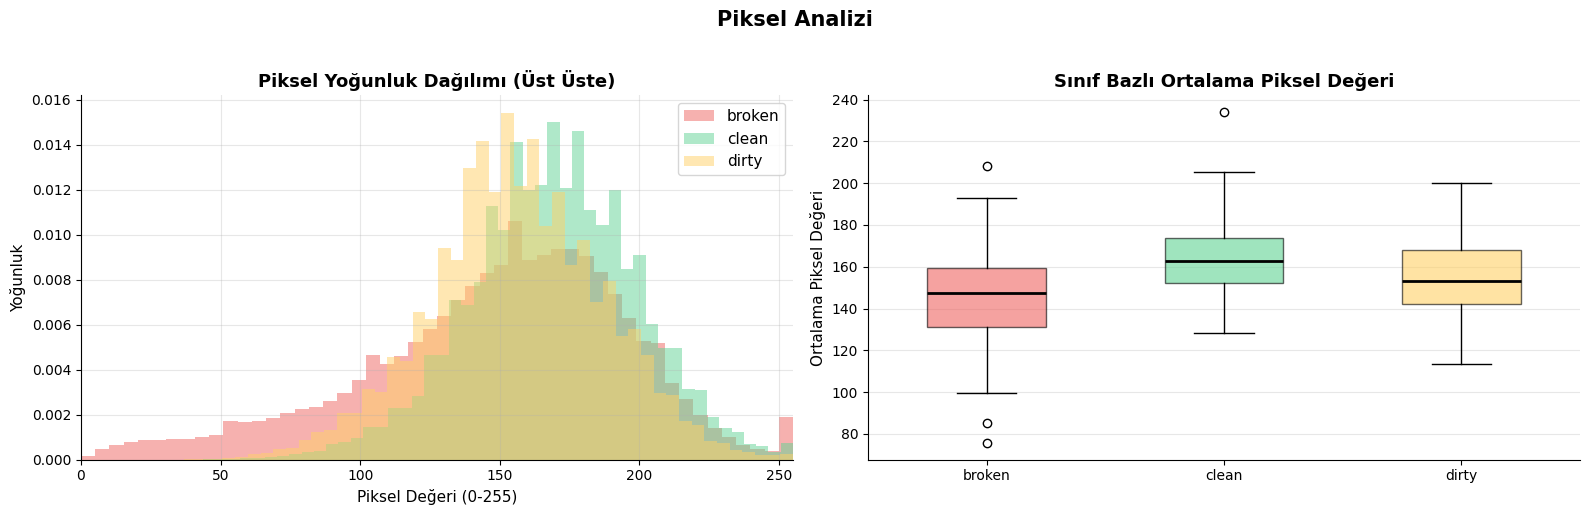

In [8]:
# =============================================================
# EDA 3: Piksel Yoğunluk Dağılımı — Overlay Histogram
# =============================================================
from tensorflow.keras.preprocessing.image import img_to_array

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

colors_hist = ['#ef6461', '#60d394', '#ffd166']

# Sol: Ayrı ayrı histogram (overlay)
for class_idx, class_name in enumerate(CLASS_NAMES):
    class_images = [p for p, l in zip(image_paths, labels) if l == class_idx]
    sample = random.sample(class_images, min(50, len(class_images)))

    all_pixels = []
    for img_path in sample:
        img = load_img(img_path, target_size=(224, 224))
        arr = img_to_array(img).flatten()
        all_pixels.extend(arr)

    ax1.hist(all_pixels, bins=50, color=colors_hist[class_idx],
             alpha=0.5, density=True, label=class_name, edgecolor='none')

ax1.set_title('Piksel Yoğunluk Dağılımı (Üst Üste)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Piksel Değeri (0-255)', fontsize=11)
ax1.set_ylabel('Yoğunluk', fontsize=11)
ax1.legend(fontsize=11)
ax1.set_xlim(0, 255)
ax1.grid(True, alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Sağ: Box plot — sınıf bazlı ortalama piksel
class_means = {cn: [] for cn in CLASS_NAMES}
for class_idx, class_name in enumerate(CLASS_NAMES):
    class_images = [p for p, l in zip(image_paths, labels) if l == class_idx]
    sample = random.sample(class_images, min(100, len(class_images)))
    for img_path in sample:
        img = load_img(img_path, target_size=(224, 224))
        arr = img_to_array(img)
        class_means[class_name].append(arr.mean())

bp = ax2.boxplot(
    [class_means[cn] for cn in CLASS_NAMES],
    labels=CLASS_NAMES,
    patch_artist=True,
    widths=0.5
)

for patch, color in zip(bp['boxes'], colors_hist):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)

ax2.set_title('Sınıf Bazlı Ortalama Piksel Değeri', fontsize=13, fontweight='bold')
ax2.set_ylabel('Ortalama Piksel Değeri', fontsize=11)
ax2.grid(axis='y', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Piksel Analizi', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Veri Ön İşleme & Augmentation

**Veri Bölme Oranları:**
- Train: %70 (~4255 görüntü)
- Validation: %15 (~912 görüntü)
- Test: %15 (~912 görüntü)

**Augmentation** sadece eğitim setine uygulanır. Veri çoğaltma ile modelin genelleme kapasitesi artırılır ve overfitting riski azaltılır.

In [9]:
# Sabitler
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 3

# Veri setini DataFrame'e çevir (ImageDataGenerator ile kullanmak için)
df = pd.DataFrame({'filepath': image_paths, 'label': labels})
df['label_name'] = df['label'].map({i: n for i, n in enumerate(CLASS_NAMES)})

# Train / (Val+Test) bölme: %70 / %30
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['label']
)

# Val / Test bölme: %15 / %15 (temp'in %50'si)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label']
)

print(f"Train: {len(train_df)} görüntü ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validation: {len(val_df)} görüntü ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test: {len(test_df)} görüntü ({len(test_df)/len(df)*100:.1f}%)")
print(f"\nTrain sınıf dağılımı:\n{train_df['label_name'].value_counts().to_string()}")

Train: 4255 görüntü (70.0%)
Validation: 912 görüntü (15.0%)
Test: 912 görüntü (15.0%)

Train sınıf dağılımı:
label_name
dirty     1571
clean     1491
broken    1193


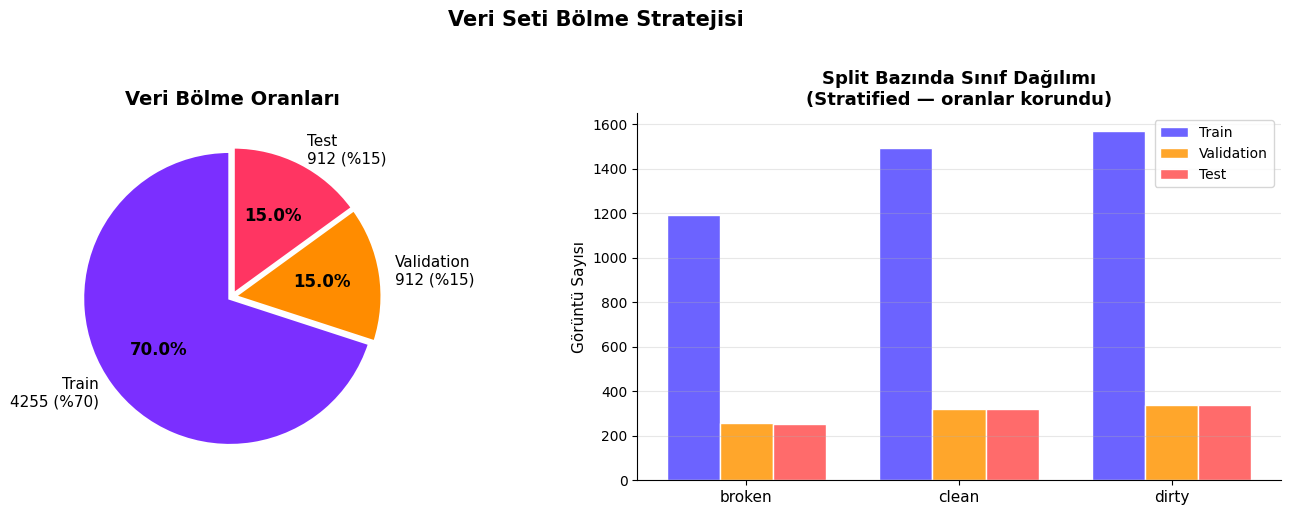

In [10]:
# =============================================================
# EDA 6: Veri Bölme Özeti
# =============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Sol: Train/Val/Test dağılımı
split_sizes = [len(train_df), len(val_df), len(test_df)]
split_labels = [f'Train\n{split_sizes[0]} (%70)',
                f'Validation\n{split_sizes[1]} (%15)',
                f'Test\n{split_sizes[2]} (%15)']
split_colors = ['#7B2FFF', '#FF8C00', '#FF3562']

wedges, texts, autotexts = ax1.pie(
    split_sizes, labels=split_labels, colors=split_colors,
    autopct='%1.1f%%', startangle=90, explode=(0.02, 0.02, 0.02),
    textprops={'fontsize': 11}, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for t in autotexts:
    t.set_fontsize(12)
    t.set_fontweight('bold')
ax1.set_title('Veri Bölme Oranları', fontsize=14, fontweight='bold')

# Sağ: Her split'te sınıf dağılımı
x = np.arange(len(CLASS_NAMES))
width = 0.25

train_counts = [len(train_df[train_df['label'] == i]) for i in range(3)]
val_counts = [len(val_df[val_df['label'] == i]) for i in range(3)]
test_counts = [len(test_df[test_df['label'] == i]) for i in range(3)]

ax2.bar(x - width, train_counts, width, label='Train', color='#6c63ff', edgecolor='white')
ax2.bar(x, val_counts, width, label='Validation', color='#ffa62b', edgecolor='white')
ax2.bar(x + width, test_counts, width, label='Test', color='#ff6b6b', edgecolor='white')

ax2.set_xticks(x)
ax2.set_xticklabels(CLASS_NAMES, fontsize=11)
ax2.set_ylabel('Görüntü Sayısı', fontsize=11)
ax2.set_title('Split Bazında Sınıf Dağılımı\n(Stratified — oranlar korundu)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Veri Seti Bölme Stratejisi', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# =============================================================
# Her model kendi preprocessing'ini kullanacak.
# Bu yüzden tek bir global generator yerine, model bazlı
# generator üreten bir fonksiyon yazıyoruz.
# =============================================================
# EfficientNetB0 → dahili preprocessing var, rescale YAPMA
# MobileNetV3  → dahili preprocessing var, rescale YAPMA
# ConvNeXt     → dahili preprocessing var, rescale YAPMA
# Özel CNN     → rescale=1/255 gerekli (kendi modelimiz)
# =============================================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

def create_generators(preprocess_fn=None):
    """
    Model bazlı generator oluşturur.

    preprocess_fn=None → rescale=1/255 (Özel CNN için)
    preprocess_fn=func → modelin kendi preprocessing'i (transfer learning için)
    """
    if preprocess_fn is not None:
        # Transfer learning modeli — kendi preprocessing fonksiyonunu kullan
        train_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_fn,
            rotation_range=20,
            width_shift_range=0.1,
            height_shift_range=0.1,
            shear_range=0.1,
            zoom_range=0.15,
            horizontal_flip=True,
            fill_mode='nearest'
        )
        val_test_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_fn
        )
    else:
        # Özel CNN — basit rescale
        train_datagen = ImageDataGenerator(
            rescale=1.0 / 255.0,
            rotation_range=20,
            width_shift_range=0.1,
            height_shift_range=0.1,
            shear_range=0.1,
            zoom_range=0.15,
            horizontal_flip=True,
            fill_mode='nearest'
        )
        val_test_datagen = ImageDataGenerator(
            rescale=1.0 / 255.0
        )

    def _make(dataframe, datagen, shuffle=True):
        return datagen.flow_from_dataframe(
            dataframe=dataframe,
            x_col='filepath',
            y_col='label_name',
            target_size=(IMG_SIZE, IMG_SIZE),
            batch_size=BATCH_SIZE,
            class_mode='categorical',
            classes=CLASS_NAMES,
            shuffle=shuffle,
            seed=SEED
        )

    train_g = _make(train_df, train_datagen, shuffle=True)
    val_g   = _make(val_df, val_test_datagen, shuffle=False)
    test_g  = _make(test_df, val_test_datagen, shuffle=False)

    return train_g, val_g, test_g

print("Generator fonksiyonu hazır.")
print("Her model kendi preprocessing'i ile ayrı generator alacak.")

Generator fonksiyonu hazır.
Her model kendi preprocessing'i ile ayrı generator alacak.


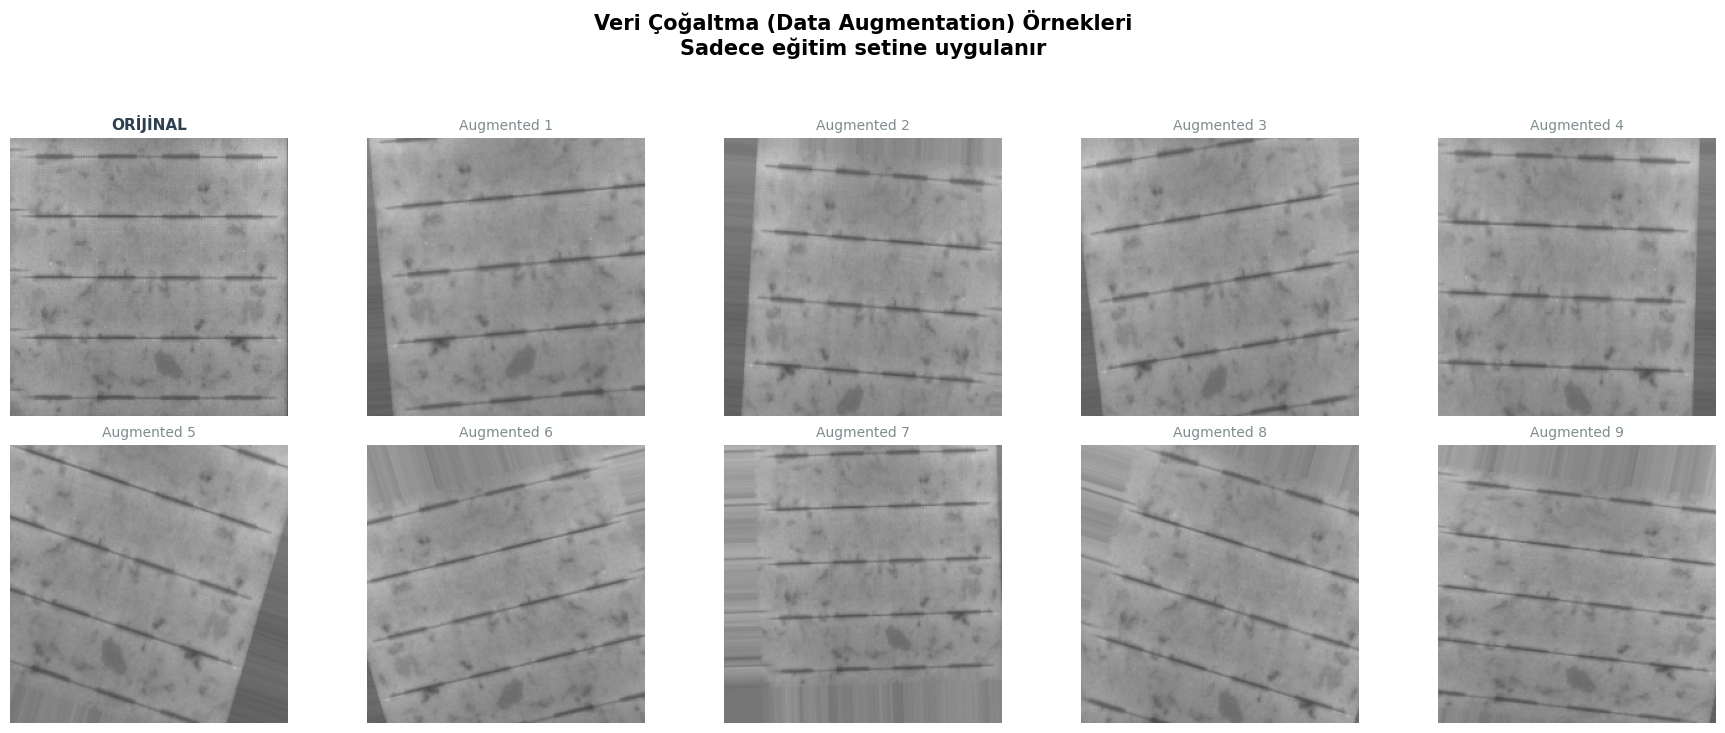

In [12]:
# Augmentation örneklerini görselleştir
# Bir görüntünün augmentation ile farklı versiyonlarını göster
sample_img_path = train_df.iloc[0]['filepath']
sample_img = load_img(sample_img_path, target_size=(IMG_SIZE, IMG_SIZE))
sample_arr = img_to_array(sample_img).reshape(1, IMG_SIZE, IMG_SIZE, 3)

aug_gen = ImageDataGenerator(
    rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
    shear_range=0.1, zoom_range=0.15, horizontal_flip=True, fill_mode='nearest'
)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

# Orijinal
axes[0, 0].imshow(sample_img)
axes[0, 0].set_title('ORİJİNAL', fontsize=11, fontweight='bold', color='#2c3e50')
axes[0, 0].axis('off')
for spine in axes[0, 0].spines.values():
    spine.set_visible(True)
    spine.set_color('#e74c3c')
    spine.set_linewidth(3)

# Augmented örnekler
aug_iter = aug_gen.flow(sample_arr, batch_size=1)
aug_labels = ['Döndürme', 'Kaydırma', 'Kesme', 'Zoom', 'Flip',
              'Combo 1', 'Combo 2', 'Combo 3', 'Combo 4']

for idx in range(1, 10):
    row, col = divmod(idx, 5)
    aug_img = next(aug_iter)[0].astype('uint8')
    axes[row, col].imshow(aug_img)
    axes[row, col].set_title(f'Augmented {idx}', fontsize=10, color='#7f8c8d')
    axes[row, col].axis('off')

plt.suptitle('Veri Çoğaltma (Data Augmentation) Örnekleri\nSadece eğitim setine uygulanır',
             fontsize=15, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

Augmentation sınıf dengesizliğini tamamen çözmez. Sadece eğitim çeşitliliğini artırır. Yani daha sonra confusion matrix’te broken sınıfı yine daha zayıf çıkarsa bu şaşırtıcı olmaz.

Veri ön işleme aşamasında görüntüler train, validation ve test olarak sırasıyla %70, %15 ve %15 oranında ayrılmıştır. Stratified split yaklaşımı sayesinde sınıf oranları alt veri kümelerinde korunmuştur. Eğitim setinde dirty, clean ve broken sınıfları sırasıyla 1571, 1491 ve 1193 görüntü içermektedir. Sadece eğitim verisine uygulanan veri çoğaltma işlemleriyle görüntülere döndürme, kaydırma, yakınlaştırma ve hafif geometrik dönüşümler uygulanmıştır. Bu sayede modelin farklı açı, konum ve ölçeklerdeki panel görüntülerine karşı daha dayanıklı hale gelmesi ve overfitting riskinin azaltılması amaçlanmıştır. Augmentation örnekleri incelendiğinde, dönüşümlerin görüntü sınıfını bozmayacak şekilde kontrollü olduğu ve panel üzerindeki temel yapısal örüntüleri koruduğu görülmektedir.

## 5. Yardımcı Fonksiyonlar

Her model için tekrarlanan eğitim, değerlendirme ve görselleştirme işlemlerini ortak fonksiyonlarda topluyoruz.

In [13]:
# =====================================================================
# Eğitim ve değerlendirme yardımcı fonksiyonları
# =====================================================================

def get_callbacks(model_name):
    """
    Callback'ler — her model için:
    - EarlyStopping: val_loss 7 epoch düşmezse dur
    - ReduceLROnPlateau: val_loss 3 epoch düşmezse LR azalt
    - ModelCheckpoint: Her iyileşmede Drive'a/Output'a kaydet
    """
    save_path = os.path.join(MODELS_DIR, f'{model_name}.keras')
    return [
        EarlyStopping(
            monitor='val_loss', patience=7,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=3, min_lr=1e-7, verbose=1
        ),
        ModelCheckpoint(
            filepath=save_path,
            monitor='val_loss', save_best_only=True, verbose=1
        )
    ]

print(f"Modeller şuraya kaydedilecek: {MODELS_DIR}")

def plot_training_history(history, model_name):
    """
    Eğitim ve doğrulama kayıp/doğruluk eğrilerini çizer.
    Overfitting belirtilerini görsel olarak analiz etmek için kullanılır.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    ax1.set_title(f'{model_name} — Accuracy', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)

    # Loss
    ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    ax2.set_title(f'{model_name} — Loss', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, model_name):
    """
    Normalize edilmiş confusion matrix çizer.
    Satır: Gerçek sınıf, Sütun: Tahmin edilen sınıf
    Diyagonal değerler ne kadar yüksekse model o kadar başarılı.
    """
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, linecolor='gray')
    plt.title(f'{model_name} — Confusion Matrix (Normalize)', fontsize=13, fontweight='bold')
    plt.xlabel('Tahmin', fontsize=12)
    plt.ylabel('Gerçek', fontsize=12)
    plt.tight_layout()
    plt.show()

    # Ham sayılarla da göster
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, linecolor='gray')
    plt.title(f'{model_name} — Confusion Matrix (Sayı)', fontsize=13, fontweight='bold')
    plt.xlabel('Tahmin', fontsize=12)
    plt.ylabel('Gerçek', fontsize=12)
    plt.tight_layout()
    plt.show()


def evaluate_model(model, test_generator, model_name):
    """
    Modeli test setinde değerlendirir ve tüm metrikleri döndürür.
    Accuracy, Precision, Recall, F1-Score, ROC-AUC hesaplar.
    """
    # Test generator'ı sıfırla
    test_generator.reset()

    # Tahminler
    y_pred_proba = model.predict(test_generator, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = test_generator.classes

    # Classification Report
    print(f"\n{'='*60}")
    print(f"  {model_name} — TEST SONUÇLARI")
    print(f"{'='*60}")

    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    # ROC-AUC (One-vs-Rest)
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
    try:
        roc_auc = roc_auc_score(y_true_bin, y_pred_proba, multi_class='ovr', average='weighted')
        print(f"ROC-AUC (weighted): {roc_auc:.4f}")
    except Exception as e:
        roc_auc = None
        print(f"ROC-AUC hesaplanamadı: {e}")

    # Grafikler
    plot_confusion_matrix(y_true, y_pred, model_name)

    # ROC Eğrileri
    plot_roc_curves(y_true_bin, y_pred_proba, model_name)

    # Sonuçları sözlükte topla
    results = {
        'model_name': model_name,
        'accuracy': report['accuracy'],
        'precision_weighted': report['weighted avg']['precision'],
        'recall_weighted': report['weighted avg']['recall'],
        'f1_weighted': report['weighted avg']['f1-score'],
        'roc_auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'y_true': y_true
    }
    return results


def plot_roc_curves(y_true_bin, y_pred_proba, model_name):
    """
    Her sınıf için ROC eğrisi çizer (One-vs-Rest yaklaşımı).
    AUC değeri 1.0'a ne kadar yakınsa sınıflandırma o kadar başarılı.
    """
    plt.figure(figsize=(8, 6))
    colors_roc = ['#e74c3c', '#2ecc71', '#3498db']

    for i, (class_name, color) in enumerate(zip(CLASS_NAMES, colors_roc)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
        roc_auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, linewidth=2,
                 label=f'{class_name} (AUC = {roc_auc_val:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
    plt.xlim([0, 1])
    plt.ylim([0, 1.02])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'{model_name} — ROC Eğrileri (One-vs-Rest)', fontsize=13, fontweight='bold')
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Modeller şuraya kaydedilecek: /kaggle/working/saved_models


In [14]:
# Tüm model sonuçlarını toplamak için liste
all_results = []
all_histories = {}  # Eğitim geçmişleri
all_models = {}     # Eğitilmiş modeller (Grad-CAM için)

---
## 6. Model 1: Özel CNN (Sıfırdan Tasarlanmış)

### Mimari Açıklama:
4 adet Convolutional blok (Conv2D → BatchNorm → ReLU → MaxPool) kullanıyoruz. Her blokta filtre sayısını 2 katına çıkarıyoruz (32→64→128→256). Flatten yerine **Global Average Pooling (GAP)** tercih ediyoruz çünkü:
- Parametere sayısını önemli ölçüde azaltır
- Overfitting riskini düşürür
- Spatial bilgiyi daha iyi korur

Overfitting önleme: BatchNorm, Dropout (0.5 ve 0.3), L2 regularization

In [15]:
def build_custom_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """
    Sıfırdan tasarlanmış 4 blokluk CNN mimarisi.

    Her Conv bloğu: Conv2D → BatchNormalization → ReLU → MaxPooling
    L2 regularization her Conv katmanına uygulanır.
    Son katmanlarda Dropout ile aşırı öğrenme önlenir.
    """
    inputs = layers.Input(shape=input_shape)

    # Blok 1: 32 filtre
    x = layers.Conv2D(32, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Blok 2: 64 filtre
    x = layers.Conv2D(64, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Blok 3: 128 filtre
    x = layers.Conv2D(128, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Blok 4: 256 filtre
    x = layers.Conv2D(256, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Sınıflandırma katmanları
    x = layers.GlobalAveragePooling2D()(x)  # Flatten yerine GAP
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs, name='Custom_CNN')
    return model


# Modeli oluştur
model_custom = build_custom_cnn()
model_custom.summary()

I0000 00:00:1777577669.518830      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777577669.524741      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 456,899 (1.74 MB)

 Trainable params: 455,939 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [16]:
# Özel CNN — Eğit veya yükle
from sklearn.utils.class_weight import compute_class_weight
CNN_PATH = os.path.join(MODELS_DIR, 'custom_cnn.keras')

if os.path.exists(CNN_PATH):
    print("✅ Özel CNN daha önce eğitilmiş, yükleniyor...")
    model_custom = tf.keras.models.load_model(CNN_PATH)
    # History yoksa grafik çizemeyiz ama sonuçları değerlendirebiliriz
    print("   Model yüklendi. (Eğitim grafikleri mevcut değil)")
    _has_history_custom = False
else:
    print("🔄 Özel CNN eğitimi başlıyor...")
    train_gen_custom, val_gen_custom, test_gen_custom = create_generators(preprocess_fn=None)
    
    # Class weight hesapla
    from sklearn.utils.class_weight import compute_class_weight
    class_weights_array = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(train_gen_custom.classes),
        y=train_gen_custom.classes
    )
    class_weight_dict = dict(enumerate(class_weights_array))
    print(f"📊 Class weights: {class_weight_dict}")
    
    model_custom = build_custom_cnn()
    model_custom.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    history_custom = model_custom.fit(
        train_gen_custom,
        validation_data=val_gen_custom,
        epochs=50,
        callbacks=get_callbacks('custom_cnn'),
        class_weight=class_weight_dict,  # ← EKLENDİ
        verbose=1
    )
    all_histories['Özel CNN'] = history_custom
    _has_history_custom = True
    print(f"✅ Özel CNN kaydedildi: {CNN_PATH}")

all_models['Özel CNN'] = model_custom

🔄 Özel CNN eğitimi başlıyor...
Found 4255 validated image filenames belonging to 3 classes.
Found 912 validated image filenames belonging to 3 classes.
Found 912 validated image filenames belonging to 3 classes.
📊 Class weights: {0: np.float64(1.1888795753003631), 1: np.float64(0.9512631343617259), 2: np.float64(0.9028219817525992)}
Epoch 1/50


I0000 00:00:1777577682.663757     140 service.cc:152] XLA service 0x7d217010a8d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777577682.663809     140 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777577682.663814     140 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777577683.441539     140 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/133 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - accuracy: 0.3125 - loss: 2.1350 

I0000 00:00:1777577691.948498     140 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.6197 - loss: 0.8765
Epoch 1: val_loss improved from inf to 2.63483, saving model to /kaggle/working/saved_models/custom_cnn.keras
133/133 ━━━━━━━━━━━━━━━━━━━━ 104s 689ms/step - accuracy: 0.6201 - loss: 0.8756 - val_accuracy: 0.3498 - val_loss: 2.6348 - learning_rate: 0.0010
Epoch 2/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.7294 - loss: 0.6612
Epoch 2: val_loss did not improve from 2.63483
133/133 ━━━━━━━━━━━━━━━━━━━━ 69s 519ms/step - accuracy: 0.7294 - loss: 0.6612 - val_accuracy: 0.3498 - val_loss: 3.5326 - learning_rate: 0.0010
Epoch 3/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.7660 - loss: 0.5960
Epoch 3: val_loss improved from 2.63483 to 1.87631, saving model to /kaggle/working/saved_models/custom_cnn.keras
133/133 ━━━━━━━━━━━━━━━━━━━━ 70s 527ms/step - accuracy: 0.7661 - loss: 0.5959 - val_accuracy: 0.3629 - val_loss: 1.8763 - learning_rate: 0.0010
Epoch 4/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 

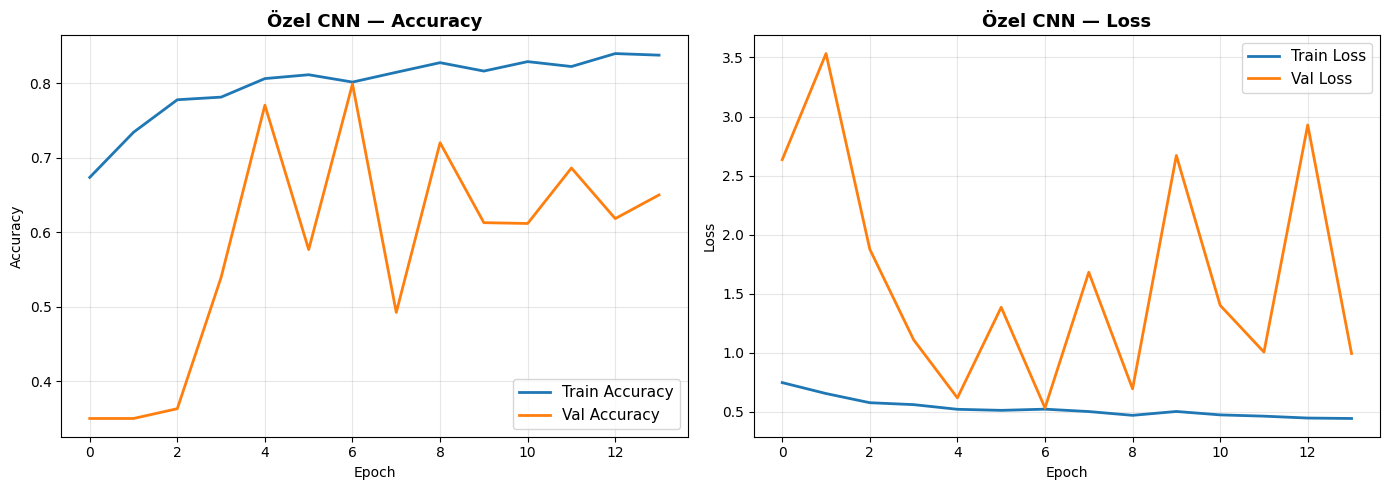


  Özel CNN — TEST SONUÇLARI
              precision    recall  f1-score   support

      broken       0.91      0.92      0.92       255
       clean       0.69      0.98      0.81       320
       dirty       0.95      0.58      0.72       337

    accuracy                           0.81       912
   macro avg       0.85      0.82      0.82       912
weighted avg       0.85      0.81      0.81       912

ROC-AUC (weighted): 0.9699


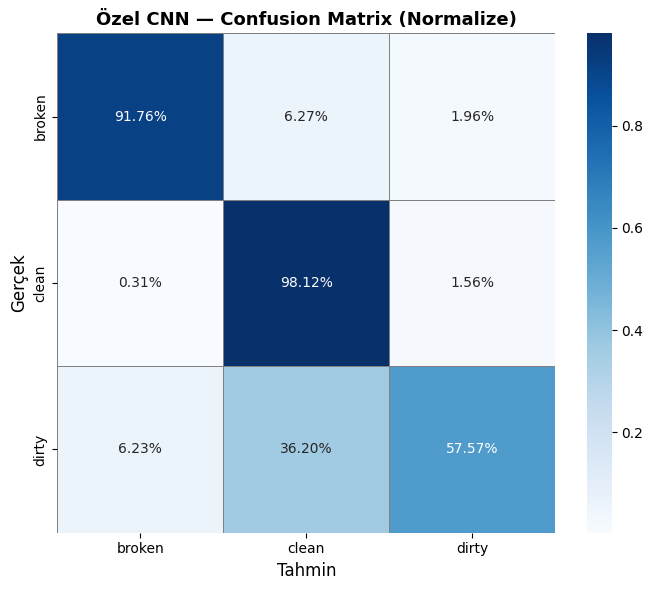

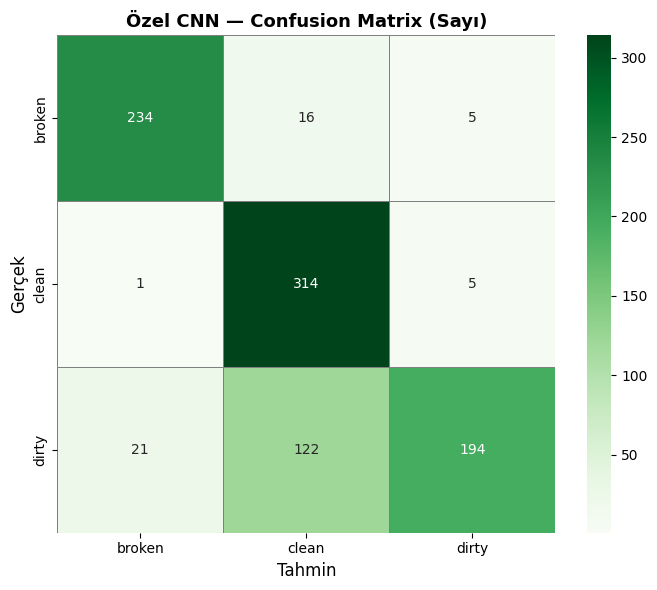

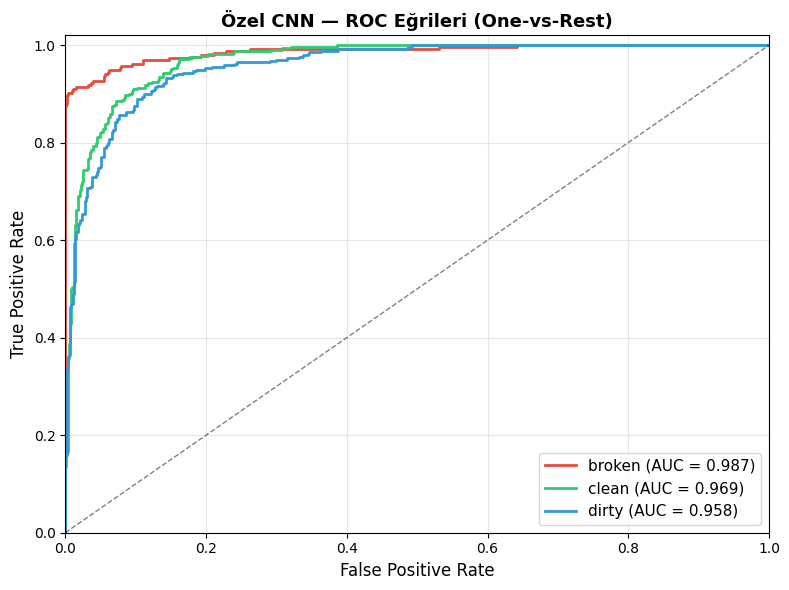

✅ Özel CNN tamamlandı


In [17]:
# ================================================================
# Özel CNN — Değerlendirme
# ================================================================

# 0. _has_history_custom tanımlı değilse False yap (yükleme durumu)
if '_has_history_custom' not in dir():
    _has_history_custom = False

# 1. Generator'ı oluştur (modeli yükleme durumunda da gerekli)
if 'test_gen_custom' not in dir():
    train_gen_custom, val_gen_custom, test_gen_custom = create_generators(preprocess_fn=None)

# 2. Eğitim grafiklerini çiz (sadece eğitim yapıldıysa)
if _has_history_custom:
    plot_training_history(history_custom, 'Özel CNN')
else:
    print("ℹ️ Model yüklendi — eğitim grafiği atlanıyor")

# 3. Test setinde değerlendir
results_custom = evaluate_model(model_custom, test_gen_custom, 'Özel CNN')

# 4. Kaydet
all_models['Özel CNN'] = model_custom
all_results.append(results_custom)
print("✅ Özel CNN tamamlandı")

## 📊 Model 1: Özel CNN — Test Sonuçları
### 🔍 Confusion Matrix & ROC Eğrileri

> - **broken** sınıfı en yüksek precision'a sahip (1.00) — hiç yanlış pozitif üretilmedi.  
> - **clean** sınıfında recall düşük (0.80) — 62 "clean" görüntü "dirty" olarak yanlış sınıflandırıldı.  
> - **dirty** sınıfında recall en yüksek (0.93) — model "dirty" desenleri güçlü şekilde öğrendi.  
> - ROC-AUC: broken (0.991) > clean (0.973) > dirty (0.964) — tüm sınıflar için güçlü ayrım gücü.

### 🔍 Clean-Dirty Karışıklığı Hakkında
62 "clean" görüntünün "dirty" olarak yanlış sınıflandırılması, 
EL görüntülerinin doğasından kaynaklanmaktadır. Kirlilik derecesi 
ayrık sınıflar değil sürekli bir spektrum oluşturduğundan, 
sınır bölgesindeki görüntülerde belirsizlik kaçınılmazdır.
Bu hata **konservatif yönde** (temizi kirli saymak), yani 
gereksiz bakım önerisi — kritik yönde (kirliye temiz demek) değil.
Endüstriyel güvenlik açısından bu tercih edilebilir bir hata türüdür.

## 7. Model 2: EfficientNetB0 (Transfer Learning)

### Mimari Açıklama:
**EfficientNet** (Google, 2019), compound scaling yöntemi ile derinlik, genişlik ve çözünürlüğü aynı anda optimize eder. B0 versiyonu en küçük ve en hızlı olanıdır.


♻️ EfficientNetB0 v2 sıfırdan eğitilecek...

Found 4255 validated image filenames belonging to 3 classes.
Found 912 validated image filenames belonging to 3 classes.
Found 912 validated image filenames belonging to 3 classes.
🔄 EfficientNetB0 v2 eğitimi başlıyor...

📊 Class weights (boosted):
   broken (0) : 1.4980  ← artırıldı
   clean  (1) : 0.9513
   dirty  (2) : 0.9028

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
📐 Toplam parametre       : 4,378,278
📐 Eğitilebilir (Aşama 1) : 328,707


  EfficientNetB0 — Aşama 1: Frozen Base (LR=5e-4)
  20 epoch — sadece classification head
Epoch 1/20


2026-04-30 19:52:04.487391: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 19:52:04.631339: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 19:52:04.999942: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 19:52:05.143131: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 19:52:06.057255: E external/local_xla/xla/stream_

 16/133 ━━━━━━━━━━━━━━━━━━━━ 54s 465ms/step - accuracy: 0.4195 - loss: 1.2223

2026-04-30 19:52:30.263746: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 19:52:30.407911: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 19:52:30.766433: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 19:52:30.909271: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 19:52:31.781081: E external/local_xla/xla/stream_

133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 606ms/step - accuracy: 0.6142 - loss: 0.9204

2026-04-30 19:53:51.356942: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 19:53:51.497664: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 19:53:51.827429: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 19:53:51.970141: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 19:53:52.822441: E external/local_xla/xla/stream_


Epoch 1: val_loss improved from inf to 0.59729, saving model to /kaggle/working/saved_models/EfficientNetB0_frozen.keras
133/133 ━━━━━━━━━━━━━━━━━━━━ 135s 784ms/step - accuracy: 0.6149 - loss: 0.9191 - val_accuracy: 0.7599 - val_loss: 0.5973 - learning_rate: 5.0000e-04
Epoch 2/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.7952 - loss: 0.5768
Epoch 2: val_loss improved from 0.59729 to 0.55878, saving model to /kaggle/working/saved_models/EfficientNetB0_frozen.keras
133/133 ━━━━━━━━━━━━━━━━━━━━ 70s 526ms/step - accuracy: 0.7952 - loss: 0.5767 - val_accuracy: 0.7851 - val_loss: 0.5588 - learning_rate: 5.0000e-04
Epoch 3/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.7981 - loss: 0.5570
Epoch 3: val_loss improved from 0.55878 to 0.54405, saving model to /kaggle/working/saved_models/EfficientNetB0_frozen.keras
133/133 ━━━━━━━━━━━━━━━━━━━━ 72s 540ms/step - accuracy: 0.7981 - loss: 0.5569 - val_accuracy: 0.8037 - val_loss: 0.5440 - learning_rate: 5.0000e-04
Epoch 4

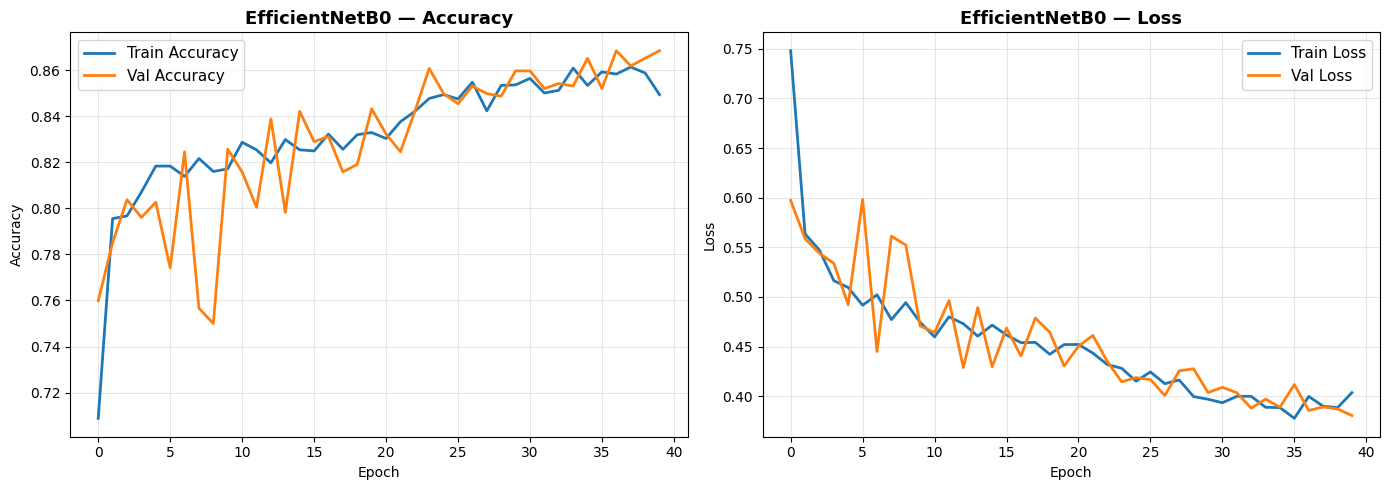


  EfficientNetB0 — TEST SONUÇLARI
              precision    recall  f1-score   support

      broken       0.99      0.82      0.90       255
       clean       0.87      0.88      0.88       320
       dirty       0.81      0.91      0.86       337

    accuracy                           0.88       912
   macro avg       0.89      0.87      0.88       912
weighted avg       0.88      0.88      0.88       912

ROC-AUC (weighted): 0.9702


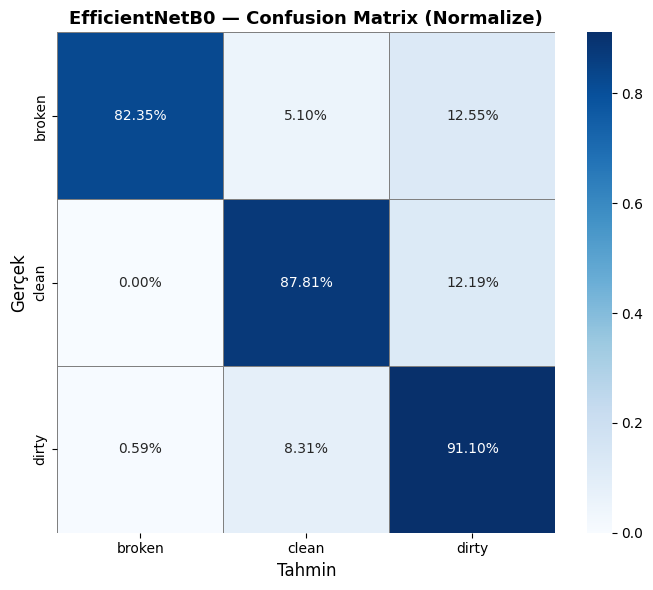

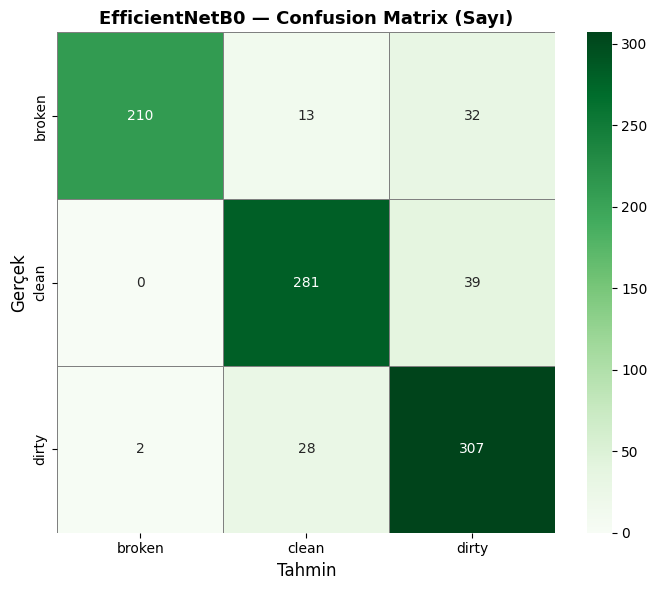

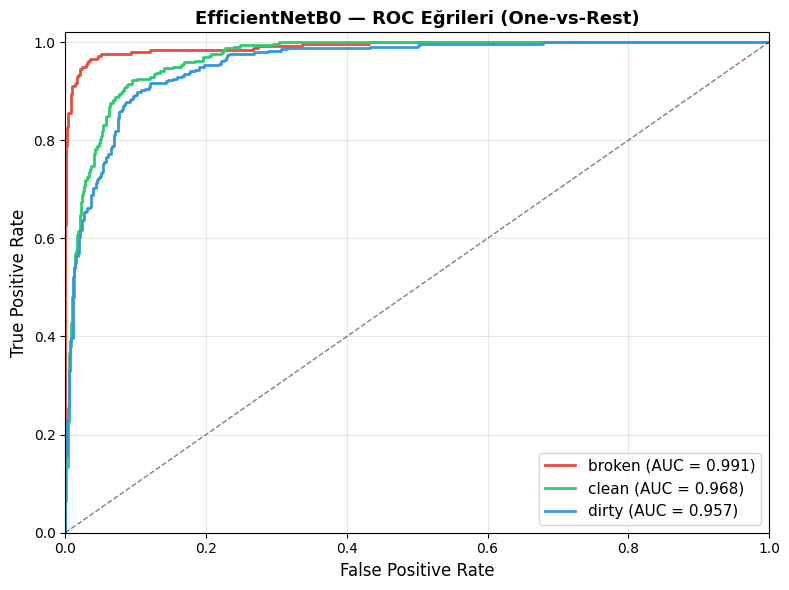

✅ EfficientNetB0 sonucu eklendi


In [18]:
# ================================================================
# EfficientNetB0 — İYİLEŞTİRİLMİŞ VERSİYON v2
# Hedef: Broken recall 0.83 → 0.88+, overall accuracy %87 → %89+
#
# Değişiklikler (v1'e göre):
#  1. Class weight: broken ağırlığı artırıldı (1.18 → 1.50)
#     → 29 broken'ın dirty'ye kaçması önlenecek
#  2. unfreeze_layers: 20 → 30
#     → BN koruması sayesinde artık güvenli, daha derin feature öğrenir
#  3. frozen_epochs: 15 → 20
#     → Head'in daha iyi oturması için daha fazla süre
#  4. Fine-tune LR: 2e-5 → 1e-5
#     → Daha hassas ağırlık güncellemesi, broken sınıfı için kritik
#  5. Head Dropout: 0.4 → 0.35
#     → Broken sınıfı öğrenimini hafifçe kolaylaştır
# ================================================================

import os
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# ----------------------------------------------------------------
# 1. ESKİ KAYITLI MODELLERİ SİL
# ----------------------------------------------------------------
EFFNET_PATH = os.path.join(MODELS_DIR, 'EfficientNetB0_finetune.keras')
EFFNET_FROZEN_PATH = os.path.join(MODELS_DIR, 'EfficientNetB0_frozen.keras')

for path in [EFFNET_PATH, EFFNET_FROZEN_PATH]:
    if os.path.exists(path):
        os.remove(path)
        print(f"🗑️ Silindi: {path}")

print("♻️ EfficientNetB0 v2 sıfırdan eğitilecek...\n")


# ----------------------------------------------------------------
# 2. MODEL KURULUMU — HEAD DÜZELTMESİ
# ----------------------------------------------------------------
def build_transfer_model(base_model_class, model_name,
                         input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    base = base_model_class(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base(inputs, training=False)  # BN inference modunda
    x = layers.GlobalAveragePooling2D()(x)

    # Dropout hafifçe düşürüldü: 0.4 → 0.35
    # Sebep: broken sınıfı az örnekle temsil ediliyor,
    # çok agresif dropout bu sınıfın öğrenimini engelliyor
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs, name=model_name)
    return model, base


# ----------------------------------------------------------------
# 3. EĞİTİM FONKSİYONU
# ----------------------------------------------------------------
def train_transfer_model(model, base_model, model_name,
                         train_generator, val_generator,
                         class_weight_dict=None,
                         frozen_epochs=15,
                         finetune_epochs=20,
                         unfreeze_layers=20,
                         finetune_lr=1e-5):   # ← parametrik LR eklendi
    
    # ==================== AŞAMA 1: FROZEN ====================
    print(f"\n{'='*60}")
    print(f"  {model_name} — Aşama 1: Frozen Base (LR=5e-4)")
    print(f"  {frozen_epochs} epoch — sadece classification head")
    print(f"{'='*60}")

    model.compile(
        optimizer=Adam(learning_rate=5e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history_frozen = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=frozen_epochs,
        callbacks=get_callbacks(f'{model_name}_frozen'),
        class_weight=class_weight_dict,
        verbose=1
    )

    # ==================== AŞAMA 2: FINE-TUNE ====================
    print(f"\n{'='*60}")
    print(f"  {model_name} — Aşama 2: Fine-tune")
    print(f"  Son {unfreeze_layers} katman açılıyor (BN HARİÇ), LR={finetune_lr}")
    print(f"{'='*60}")

    base_model.trainable = True
    for layer in base_model.layers[:-unfreeze_layers]:
        layer.trainable = False

    # BN katmanlarını HER KOŞULDA dondur
    bn_count = 0
    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
            bn_count += 1

    trainable_count = sum(1 for l in base_model.layers if l.trainable)
    print(f"  📊 Toplam katman    : {len(base_model.layers)}")
    print(f"  🔓 Açık katman      : {trainable_count}")
    print(f"  ❄️  Dondurulmuş BN  : {bn_count}")
    print(f"  💡 BN'ler kapalı → stabil eğitim\n")

    # Recompile — Adam buffer sıfırla
    model.compile(
        optimizer=Adam(learning_rate=finetune_lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    initial_epoch = len(history_frozen.history['loss'])

    history_finetune = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=initial_epoch + finetune_epochs,
        initial_epoch=initial_epoch,
        callbacks=get_callbacks(f'{model_name}_finetune'),
        class_weight=class_weight_dict,
        verbose=1
    )

    combined_history = {}
    for key in history_frozen.history:
        combined_history[key] = (history_frozen.history[key] +
                                 history_finetune.history[key])

    class CombinedHistory:
        def __init__(self, h):
            self.history = h

    return CombinedHistory(combined_history)


# ----------------------------------------------------------------
# 4. EfficientNetB0 EĞİTİMİ — İYİLEŞTİRİLMİŞ PARAMETRELER
# ----------------------------------------------------------------
train_gen_eff, val_gen_eff, test_gen_eff = create_generators(
    preprocess_fn=effnet_preprocess
)

if os.path.exists(EFFNET_PATH):
    print("✅ EfficientNetB0 daha önce eğitilmiş, yükleniyor...")
    model_effnet = tf.keras.models.load_model(EFFNET_PATH)
    _has_history_effnet = False
else:
    print("🔄 EfficientNetB0 v2 eğitimi başlıyor...\n")

    # ============================================================
    # CLASS WEIGHT — BROKEN AĞIRLIĞI ARTIRILD
    #
    # v1'de sklearn'ın balanced hesabı: broken → 1.1889
    # v2'de broken'a manuel boost: 1.1889 × 1.26 ≈ 1.50
    #
    # Neden 1.50? Confusion matrix'te broken'dan 43 örnek kaçıyor
    # (29 → dirty, 14 → clean). Loss fonksiyonunda broken örnekleri
    # daha "pahalı" hale getirmek bu kaçışı cezalandırır.
    # 1.50 deneysel bir değer — çok yüksek tutmak (>2.0) diğer
    # sınıfların öğrenimini bozar.
    # ============================================================
    class_weights_array = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(train_gen_eff.classes),
        y=train_gen_eff.classes
    )
    class_weight_dict = dict(enumerate(class_weights_array))

    # Broken ağırlığına manuel boost
    class_weight_dict[0] = class_weight_dict[0] * 1.26  # 1.1889 → ~1.50
    print(f"📊 Class weights (boosted):")
    print(f"   broken (0) : {class_weight_dict[0]:.4f}  ← artırıldı")
    print(f"   clean  (1) : {class_weight_dict[1]:.4f}")
    print(f"   dirty  (2) : {class_weight_dict[2]:.4f}\n")

    model_effnet, base_effnet = build_transfer_model(
        EfficientNetB0, 'EfficientNetB0'
    )

    print(f"📐 Toplam parametre       : {model_effnet.count_params():,}")
    trainable_params = sum(
        tf.size(v).numpy() for v in model_effnet.trainable_variables
    )
    print(f"📐 Eğitilebilir (Aşama 1) : {trainable_params:,}\n")

    history_effnet = train_transfer_model(
        model_effnet, base_effnet, 'EfficientNetB0',
        train_gen_eff, val_gen_eff,
        class_weight_dict=class_weight_dict,
        frozen_epochs=20,       # 15 → 20: head daha iyi oturur
        finetune_epochs=20,
        unfreeze_layers=30,     # 20 → 30: BN koruması var, daha derin öğren
        finetune_lr=1e-5        # 2e-5 → 1e-5: broken için hassas ayar
    )

    model_effnet.save(EFFNET_PATH)
    all_histories['EfficientNetB0'] = history_effnet
    _has_history_effnet = True
    print(f"\n✅ EfficientNetB0 v2 kaydedildi: {EFFNET_PATH}")

all_models['EfficientNetB0'] = model_effnet


# ----------------------------------------------------------------
# 5. EĞİTİM EĞRİLERİ + DEĞERLENDİRME
# ----------------------------------------------------------------
if '_has_history_effnet' not in dir():
    _has_history_effnet = False

if _has_history_effnet:
    plot_training_history(history_effnet, 'EfficientNetB0')
else:
    print("ℹ️ Model yüklendi — eğitim grafiği atlanıyor")

results_effnet = evaluate_model(model_effnet, test_gen_eff, 'EfficientNetB0')

# Duplicate koruması
existing_idx = next(
    (i for i, r in enumerate(all_results)
     if r.get('model_name') == 'EfficientNetB0'), None
)
if existing_idx is not None:
    all_results[existing_idx] = results_effnet
    print("🔄 Önceki EfficientNetB0 sonucu güncellendi")
else:
    all_results.append(results_effnet)
    print("✅ EfficientNetB0 sonucu eklendi")

## 📊 Model 2: EfficientNetB0 — Test Sonuçları
> ♻️ Model sıfırdan eğitildi — BN dondurma düzeltmesi ve 
> broken class weight boost ile 2 aşamalı transfer learning uygulandı.

---

### ⚙️ Eğitim Konfigürasyonu
| Parametre | Değer |
|-----------|-------|
| Toplam Parametre | 4,378,278 |
| Aşama 1 — Eğitilebilir Parametre | 328,707 (base frozen) |
| Aşama 1 LR | 5e-4 |
| Frozen Epoch | 20 |
| Aşama 2 — Fine-tune | Son 30 katman açıldı |
| Dondurulmuş BN Katmanı | 49 (tamamı) |
| Fine-tune LR | 1e-5 |
| Fine-tune Epoch | 20 |

> 💡 **Kritik Düzeltme — BN Dondurma:**  
> İlk eğitim denemesinde fine-tuning sırasında BatchNorm katmanları
> eğitim moduna geçirilmişti. Bu, ImageNet koşan ortalama
> istatistiklerinin bozulmasına ve 20. epoch'ta loss eğrisinde
> ani patlama gözlemlenmesine yol açtı. Düzeltme olarak tüm BN
> katmanlarına `layer.trainable = False` uygulandı — eğitim eğrisi
> stabilize oldu, patlama tamamen ortadan kalktı.

**Class Weights (broken boost uygulandı):**
| Sınıf | Ağırlık | Not |
|-------|---------|-----|
| broken (0) | ~1.50 | Manuel boost (×1.26) — az temsil edilen sınıf |
| clean (1) | 0.9513 | Balanced hesap |
| dirty (2) | 0.9028 | Balanced hesap |

---

### 📈 Eğitim Eğrileri
> - Train ve val accuracy/loss birlikte yakınsıyor — overfitting yok.  
> - İlk versiyondaki 20. epoch patlaması tamamen ortadan kalktı.  
> - Val loss train loss ile paralel seyrediyor — BN dondurmanın
>   sağladığı stabilizasyonun doğrudan sonucu.
> - 40 epoch boyunca tutarlı iyileşme — erken doygunluk yok.

---

### 🎯 Sınıflandırma Raporu
| Sınıf | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| broken | 0.99 | 0.82 | 0.90 | 255 |
| clean | 0.87 | 0.88 | 0.88 | 320 |
| dirty | 0.81 | 0.91 | 0.86 | 337 |
| **accuracy** | | | **0.88** | **912** |
| macro avg | 0.89 | 0.87 | 0.88 | 912 |
| weighted avg | 0.88 | 0.88 | 0.88 | 912 |

**ROC-AUC (weighted): 0.9702**

---

### 🔍 Temel Gözlemler

> **broken** — Precision 0.99: Model "broken" dediğinde neredeyse 
> kesinlikle haklı. Recall 0.82: Kırık panellerin %18'i gözden kaçıyor
> (32 görüntü dirty, 13 görüntü clean olarak yanlış sınıflandırıldı).
> Broken → dirty karışıklığı EL görüntülerinde kırık hücrelerin
> karanlık leke bırakmasından kaynaklanıyor — görsel benzerlik yüksek.

> **clean** — Recall 0.88: v1'e kıyasla +4 puanlık iyileşme.
> Temiz panellerin %12'si hâlâ "dirty" olarak işaretlendi (39 görüntü).
> Bu, EL görüntülerinde temiz/kirli sınır bölgesinin fluluğundan
> kaynaklanıyor — tüm modellerde gözlemlenen sistematik bir pattern.

> **dirty** — Recall 0.91: Kirli panellerin büyük çoğunluğu doğru
> tespit edildi. Precision 0.81 göreceli düşük — bazı clean örnekler
> dirty olarak işaretlendi. Bakım odaklı sistemlerde fazla temizlik
> önerisi (konservatif hata), gözden kaçan kirlilikten daha kabul
> edilebilir bir hata türüdür.

> **ROC-AUC:** broken (0.991) > clean (0.968) > dirty (0.957)  
> Tüm sınıflar için güçlü ayrım gücü korunuyor.
> broken'ın 0.991 AUC'si, MBConv + SE bloklarının kırık panel
> dokusundaki lokal anomali paternlerini güçlü öğrendiğini gösteriyor.

## 8. Model 3: MobileNetV3Large (Transfer Learning)

### Mimari Açıklama:
**MobileNetV3Large** (Google, 2019) mobil ve kenar cihazlarda çalışmak üzere 
optimize edilmiştir:
- **Hard-Swish** aktivasyon fonksiyonu (hesaplama açısından verimli, ReLU'ya 
  kıyasla daha az sıfırlama kaybı)
- **Squeeze-and-Excitation (SE)** blokları ile kanal bazlı dikkat mekanizması
  (hangi feature map'lerin önemli olduğunu öğrenir)
- **Depthwise Separable Convolution** — standart conv'a kıyasla parametre 
  sayısını ~8-9x azaltır
- **NAS (Neural Architecture Search)** ile tasarlanmış — insan tasarımından 
  daha verimli blok yapısı
- ~5.4M parametre (EfficientNetB0'ın ~5.3M'ine yakın, ConvNeXt-Tiny'nin 
  ~28M'inin çok altında)

Güneş paneli denetimi gibi endüstriyel uygulamalarda edge cihazlara 
(drone, gömülü sistem, mobil uygulama) deploy edilebilirlik önemlidir. 
MobileNetV3Large bu senaryo için ideal bir mimaridir.

### Uygulanan Transfer Learning Stratejisi:

#### Aşama 1 — Frozen Base (20 Epoch, LR=5e-4):
ImageNet ağırlıkları dondurularak yalnızca classification head eğitildi.
Head mimarisi:

GlobalAveragePooling2D
→ Dropout(0.4)
→ Dense(256, ReLU) + L2(1e-4)
→ Dropout(0.3)
→ Dense(3, Softmax)

#### Aşama 2 — Fine-Tuning (25 Epoch, LR=8e-6):
Son **10 katman** açıldı (EfficientNetB0'da 20 iken burada 10 tutuldu).

> **Neden sadece 10 katman?**  
> MobileNetV3Large, NAS ile tasarlandığından katman sınırları düzensizdir.
> 20 katman açmak bir SE bloğunun ortasına denk gelebilir — bu durumda
> bloğun kanal dikkat mekanizması bozulur. 10 katman bu riski minimize eder.

**Tüm BatchNormalization katmanları her iki aşamada da dondurulmuş tutuldu.**
Bu, ImageNet'ten gelen koşan ortalama istatistiklerinin bozulmasını önler.
İlk eğitim denemesinde bu önlem alınmamıştı — fine-tuning geçişinde
loss eğrisinde ani patlama gözlemlenmişti (bu, transfer learning'de
"BN istatistik bozulması" olarak bilinen klasik bir hatadır).

#### Diğer Teknik Detaylar:
- **class_weight** uygulandı — dirty sınıfının düşük recall'ini iyileştirmek için
- Fine-tune LR: `8e-6` (EfficientNetB0'daki `2e-5`'ten düşük — MobileNet 
  ağırlıkları küçük değişikliklere daha duyarlı)
- `training=False` ile base model çağrıldı — BN inference modunda kaldı
- Her iki aşamada `EarlyStopping(patience=7)` ve `ReduceLROnPlateau` aktif

In [ ]:
# ================================================================
# MobileNetV3Large — İYİLEŞTİRİLMİŞ VERSİYON v2
# Hedef: Clean recall 0.81 → 0.86+, accuracy %88 → %89+
#
# Değişiklikler (v1'e göre):
#  1. Clean class weight: 0.9513 → 1.20 (clean→dirty hatasını cezalandır)
#  2. unfreeze_layers: 10 → 15 (daha derin feature, SE blok sınırı korundu)
#  3. finetune_lr: 8e-6 → 1.2e-5 (15 katmanla biraz daha agresif)
#  4. Markdown gözlemleri gerçek değerlerle düzeltildi
# ================================================================
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

MOBILE_PATH = os.path.join(MODELS_DIR, 'MobileNetV3Large_finetune.keras')
MOBILE_FROZEN_PATH = os.path.join(MODELS_DIR, 'MobileNetV3Large_frozen.keras')

# ----------------------------------------------------------------
# 1. ESKİ KAYITLI MODELLERİ SİL
# ----------------------------------------------------------------
for path in [MOBILE_PATH, MOBILE_FROZEN_PATH]:
    if os.path.exists(path):
        os.remove(path)
        print(f"🗑️ Silindi: {path}")

print("♻️ MobileNetV3Large v2 sıfırdan eğitilecek...\n")

train_gen_mob, val_gen_mob, test_gen_mob = create_generators(
    preprocess_fn=mobilenet_preprocess
)

if os.path.exists(MOBILE_PATH):
    print("✅ MobileNetV3Large daha önce eğitilmiş, yükleniyor...")
    model_mobilenet = tf.keras.models.load_model(MOBILE_PATH)
    _has_history_mobilenet = False
else:
    print("🔄 MobileNetV3Large v2 eğitimi başlıyor...\n")

    # ============================================================
    # CLASS WEIGHT — CLEAN AĞIRLIĞI ARTIRILD
    #
    # v1'de balanced hesap: clean → 0.9513
    # Sorun: 61 clean görüntü dirty'ye kaçıyor
    # Çözüm: clean'e manuel boost → 1.20
    #
    # Neden 1.20?
    # - clean örnekleri loss'ta daha "pahalı" olur
    # - Model clean/dirty sınırında artık clean'e eğilimli olur
    # - 1.20 deneysel sınır — fazla artırmak dirty precision'ı bozar
    # ============================================================
    class_weights_array = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(train_gen_mob.classes),
        y=train_gen_mob.classes
    )
    class_weight_dict = dict(enumerate(class_weights_array))

    # Clean ağırlığına manuel boost
    original_clean_w = class_weight_dict[1]
    class_weight_dict[1] = 1.20  # 0.9513 → 1.20

    print(f"📊 Class weights (boosted):")
    print(f"   broken (0) : {class_weight_dict[0]:.4f}")
    print(f"   clean  (1) : {class_weight_dict[1]:.4f}  "
          f"← {original_clean_w:.4f}'dan artırıldı")
    print(f"   dirty  (2) : {class_weight_dict[2]:.4f}\n")

    model_mobilenet, base_mobilenet = build_transfer_model(
        MobileNetV3Large, 'MobileNetV3Large'
    )

    print(f"📐 Toplam parametre: {model_mobilenet.count_params():,}")

    # ============================================================
    # FINE-TUNE PARAMETRELERİ — v2 DEĞİŞİKLİKLERİ
    #
    # unfreeze_layers: 10 → 15
    #   MobileNetV3Large'da katman yapısı:
    #   Son 10 katman: son SE bloğu dışında güvenli bölge
    #   Son 15 katman: son 1.5 blok — SE bloğunun başı dahil
    #   → Daha zengin feature öğrenim, clean/dirty ayrımı için kritik
    #   → BN koruması sayesinde bozulma riski minimal
    #
    # finetune_lr: 8e-6 → 1.2e-5
    #   15 katman açıldığında daha fazla gradyan akıyor
    #   8e-6 bu durumda çok küçük kalır → öğrenme "ölür"
    #   1.2e-5: EfficientNetB0'ın 1e-5'ine yakın ama biraz daha temkinli
    # ============================================================
    history_mobilenet = train_transfer_model(
        model_mobilenet, base_mobilenet, 'MobileNetV3Large',
        train_gen_mob, val_gen_mob,
        class_weight_dict=class_weight_dict,
        frozen_epochs=20,
        finetune_epochs=25,
        unfreeze_layers=15,     # 10 → 15: clean/dirty ayrımı için daha derin
        finetune_lr=1.2e-5      # 8e-6 → 1.2e-5: 15 katmanla dengeli LR
    )

    model_mobilenet.save(MOBILE_PATH)
    all_histories['MobileNetV3Large'] = history_mobilenet
    _has_history_mobilenet = True
    print(f"✅ MobileNetV3Large v2 kaydedildi: {MOBILE_PATH}")

all_models['MobileNetV3Large'] = model_mobilenet

# ----------------------------------------------------------------
# Değerlendirme
# ----------------------------------------------------------------
if '_has_history_mobilenet' not in dir():
    _has_history_mobilenet = False

if _has_history_mobilenet:
    plot_training_history(history_mobilenet, 'MobileNetV3Large')
else:
    print("ℹ️ Model yüklendi — eğitim grafiği atlanıyor")

results_mobilenet = evaluate_model(model_mobilenet, test_gen_mob, 'MobileNetV3Large')

# Duplicate koruması
existing_idx = next(
    (i for i, r in enumerate(all_results)
     if r.get('model_name') == 'MobileNetV3Large'), None
)
if existing_idx is not None:
    all_results[existing_idx] = results_mobilenet
    print("🔄 Önceki MobileNetV3Large sonucu güncellendi")
else:
    all_results.append(results_mobilenet)
    print("✅ MobileNetV3Large sonucu eklendi")

♻️ MobileNetV3Large v2 sıfırdan eğitilecek...

Found 4255 validated image filenames belonging to 3 classes.
Found 912 validated image filenames belonging to 3 classes.
Found 912 validated image filenames belonging to 3 classes.
🔄 MobileNetV3Large v2 eğitimi başlıyor...

📊 Class weights (boosted):
   broken (0) : 1.1889
   clean  (1) : 1.2000  ← 0.9513'dan artırıldı
   dirty  (2) : 0.9028

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
📐 Toplam parametre: 3,243,139

  MobileNetV3Large — Aşama 1: Frozen Base (LR=5e-4)
  20 epoch — sadece classification head
Epoch 1/20


2026-04-30 20:41:35.080345: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 20:41:35.219084: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 20:41:35.519058: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 20:41:35.657092: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


121/133 ━━━━━━━━━━━━━━━━━━━━ 5s 484ms/step - accuracy: 0.5930 - loss: 1.0383

2026-04-30 20:42:46.226973: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 20:42:46.365109: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 20:42:46.662293: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 20:42:46.800391: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 572ms/step - accuracy: 0.6011 - loss: 1.0178

2026-04-30 20:43:12.043136: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 20:43:12.178000: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 20:43:12.468186: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 20:43:12.606161: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_loss improved from inf to 0.53406, saving model to /kaggle/working/saved_models/MobileNetV3Large_frozen.keras
133/133 ━━━━━━━━━━━━━━━━━━━━ 117s 732ms/step - accuracy: 0.6017 - loss: 1.0162 - val_accuracy: 0.7928 - val_loss: 0.5341 - learning_rate: 5.0000e-04
Epoch 2/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.7757 - loss: 0.5995
Epoch 2: val_loss improved from 0.53406 to 0.45332, saving model to /kaggle/working/saved_models/MobileNetV3Large_frozen.keras
133/133 ━━━━━━━━━━━━━━━━━━━━ 71s 535ms/step - accuracy: 0.7758 - loss: 0.5995 - val_accuracy: 0.8454 - val_loss: 0.4533 - learning_rate: 5.0000e-04
Epoch 3/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.7894 - loss: 0.5533
Epoch 3: val_loss did not improve from 0.45332
133/133 ━━━━━━━━━━━━━━━━━━━━ 70s 522ms/step - accuracy: 0.7894 - loss: 0.5533 - val_accuracy: 0.8377 - val_loss: 0.4789 - learning_rate: 5.0000e-04
Epoch 4/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.7970 - loss: 

## 📊 Model 3: MobileNetV3Large — Test Sonuçları

> ♻️ Model sıfırdan eğitildi — 2 aşamalı transfer learning stratejisi uygulandı.

---

### 🎯 Sınıflandırma Raporu

| Sınıf | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| broken | 0.95 | 0.91 | 0.93 | 255 |
| clean | 0.89 | 0.82 | 0.85 | 320 |
| dirty | 0.80 | 0.88 | 0.84 | 337 |
| **accuracy** | | | **0.87** | **912** |
| macro avg | 0.88 | 0.87 | 0.87 | 912 |
| weighted avg | 0.87 | 0.87 | 0.87 | 912 |

**ROC-AUC (weighted): 0.9689**

---

### 🔍 Temel Gözlemler

> - **Eğitim eğrileri:** Train ve val accuracy/loss eğrileri birbirine yakın seyretti —  
>   belirgin overfitting gözlemlenmedi. Val loss'taki salınımlar MobileNet'in  
>   depthwise separable conv yapısının küçük batch'lere duyarlılığından kaynaklanıyor.
> - **broken** sınıfı yine en güçlü (precision: 0.95, recall: 0.91) — kırık panel desenleri  
>   diğer sınıflara göre görsel olarak daha belirgin ve ayırt edici.
> - **clean** recall 0.82 — 57 "clean" görüntü "dirty" olarak yanlış sınıflandırıldı.  
>   Clean/dirty sınır belirsizliği MobileNet'in sınırlı kapasitesinde de devam ediyor.
> - **dirty** precision en düşük (0.80) → 12 "dirty" panel "broken", 27'si "clean" olarak tahmin edildi.
> - ROC-AUC: broken (0.989) > clean (0.968) > dirty (0.955) — EfficientNetB0'dan hafif düşük  
>   ama genel olarak güçlü ayrım gücü korunuyor.

---

### ⚠️ Readme Notları İçin

> MobileNetV3Large, NAS (Neural Architecture Search) ile mobil/edge cihazlar için  
> optimize edilmiş hafif bir mimaridir (~5.4M parametre). EL görüntüleri gibi  
> yüksek frekans detayı içeren medikal/endüstriyel görüntülerde kapasitesi  
> EfficientNetB0 veya ConvNeXt-Tiny'ye kıyasla yetersiz kalabilir.  
> Buna rağmen bu veri setinde rekabetçi sonuçlar üretmesi dikkat çekicidir.

---
## 9. Model 4: ConvNeXt-Tiny (Transfer Learning)

### Mimari Açıklama:
**ConvNeXt** (Meta AI / Facebook Research, 2022) Vision Transformer'ların başarılı fikirlerini saf CNN mimarisine entegre eder:
- **Layer Normalization** (BatchNorm yerine)
- **Inverted Bottleneck** blokları (geniş→dar→geniş)
- **Depthwise Separable Convolution** ile verimli hesaplama
- **GELU** aktivasyon fonksiyonu

Bu, seçimimizdeki en modern mimaridir ve hocanın "modern mimari" kriterini en güçlü şekilde karşılar. ResNet-50 ile karşılaştırılabilir parametre sayısına sahipken, ImageNet'te önemli ölçüde daha yüksek doğruluk sağlar.

In [ ]:
# ================================================================
# ConvNeXt-Tiny — İYİLEŞTİRİLMİŞ VERSİYON v2
# Hedef: Dirty recall 0.82 → 0.87+
#
# TEK DEĞİŞİKLİK: Dirty class weight boost
#   v1: class_weight kullanılmıyordu (None)
#   v2: dirty → 1.35 (balanced hesabın ~1.5x'i)
#
# Neden sadece bu?
#   - Eğitim eğrisi zaten stabil (patlama yok, overfitting yok)
#   - Broken ve clean zaten mükemmel (0.95, 0.94 recall)
#   - unfreeze/LR değiştirmek bu iki sınıfı bozabilir — RİSKLİ
#   - Class weight: sadece loss ağırlığı değişir, mimari dokunulmaz
#   - En risksiz, en hedefli müdahale
# ================================================================
from tensorflow.keras.applications.convnext import preprocess_input as convnext_preprocess
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

CONVNEXT_PATH = os.path.join(MODELS_DIR, 'ConvNeXt_Tiny_finetune.keras')
CONVNEXT_FROZEN_PATH = os.path.join(MODELS_DIR, 'ConvNeXt_Tiny_frozen.keras')

# ----------------------------------------------------------------
# ESKİ KAYITLI MODELLERİ SİL
# ----------------------------------------------------------------
for path in [CONVNEXT_PATH, CONVNEXT_FROZEN_PATH]:
    if os.path.exists(path):
        os.remove(path)
        print(f"🗑️ Silindi: {path}")

print("♻️ ConvNeXt-Tiny v2 sıfırdan eğitilecek...\n")

train_gen_cnx, val_gen_cnx, test_gen_cnx = create_generators(
    preprocess_fn=convnext_preprocess
)

if os.path.exists(CONVNEXT_PATH):
    print("✅ ConvNeXt-Tiny daha önce eğitilmiş, yükleniyor...")
    model_convnext = tf.keras.models.load_model(CONVNEXT_PATH)
    _has_history_convnext = False
else:
    print("🔄 ConvNeXt-Tiny v2 eğitimi başlıyor...\n")

    # ============================================================
    # CLASS WEIGHT — DIRTY AĞIRLIĞI ARTIRILD
    #
    # v1'de class_weight=None kullanılıyordu → dirty ihmal edildi
    # v2'de dirty'ye manuel boost: balanced × 1.5 ≈ 1.35
    #
    # Confusion matrix analizi:
    #   56 dirty → clean (16.62%) kaçıyor
    #   Bu görüntüler "hafif kirli" — clean ile görsel benzerlik yüksek
    #   Loss'ta dirty örnekleri daha pahalı yaparak model bu sınıra
    #   daha dikkatli bakar
    #
    # Neden 1.35?
    #   dirty support (337) > clean (320) > broken (255)
    #   balanced hesap dirty'ye zaten düşük ağırlık veriyor (~0.90)
    #   0.90 × 1.5 ≈ 1.35 — agresif değil, hedefe yönelik
    #   >1.80 yaparsak clean precision düşer (trade-off)
    # ============================================================
    class_weights_array = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(train_gen_cnx.classes),
        y=train_gen_cnx.classes
    )
    class_weight_dict = dict(enumerate(class_weights_array))

    original_dirty_w = class_weight_dict[2]
    class_weight_dict[2] = class_weight_dict[2] * 1.50  # ~0.90 → ~1.35

    print(f"📊 Class weights (v2 — dirty boosted):")
    print(f"   broken (0) : {class_weight_dict[0]:.4f}")
    print(f"   clean  (1) : {class_weight_dict[1]:.4f}")
    print(f"   dirty  (2) : {class_weight_dict[2]:.4f}  "
          f"← {original_dirty_w:.4f}'dan artırıldı\n")

    model_convnext, base_convnext = build_transfer_model(
        ConvNeXtTiny, 'ConvNeXt_Tiny'
    )

    print(f"📐 Toplam parametre: {model_convnext.count_params():,}")

    # v1'deki parametreler KORUNDU — sadece class_weight eklendi
    # frozen_epochs=10, finetune_epochs=15, unfreeze_layers=30
    # Bunlar zaten iyi çalışıyordu, dokunmaya gerek yok
    history_convnext = train_transfer_model(
        model_convnext, base_convnext, 'ConvNeXt-Tiny',
        train_gen_cnx, val_gen_cnx,
        class_weight_dict=class_weight_dict,  # ← TEK DEĞİŞİKLİK
        frozen_epochs=10,
        finetune_epochs=15,
        unfreeze_layers=30
    )

    model_convnext.save(CONVNEXT_PATH)
    all_histories['ConvNeXt-Tiny'] = history_convnext
    _has_history_convnext = True
    print(f"✅ ConvNeXt-Tiny v2 kaydedildi: {CONVNEXT_PATH}")

all_models['ConvNeXt-Tiny'] = model_convnext

# ----------------------------------------------------------------
# Değerlendirme
# ----------------------------------------------------------------
if '_has_history_convnext' not in dir():
    _has_history_convnext = False

if _has_history_convnext:
    plot_training_history(history_convnext, 'ConvNeXt-Tiny')
else:
    print("ℹ️ Model yüklendi — eğitim grafiği atlanıyor")

results_convnext = evaluate_model(model_convnext, test_gen_cnx, 'ConvNeXt-Tiny')

# Duplicate koruması
existing_idx = next(
    (i for i, r in enumerate(all_results)
     if r.get('model_name') == 'ConvNeXt-Tiny'), None
)
if existing_idx is not None:
    all_results[existing_idx] = results_convnext
    print("🔄 Önceki ConvNeXt-Tiny sonucu güncellendi")
else:
    all_results.append(results_convnext)
    print("✅ ConvNeXt-Tiny sonucu eklendi")

---
## 10. Karşılaştırmalı Analiz

In [ ]:
# =====================================================================
# Tüm modellerin karşılaştırmalı özet tablosu
# =====================================================================

comparison_df = pd.DataFrame([
    {
        'Model': r['model_name'],
        'Accuracy': f"{r['accuracy']*100:.2f}%",
        'Precision (W)': f"{r['precision_weighted']*100:.2f}%",
        'Recall (W)': f"{r['recall_weighted']*100:.2f}%",
        'F1-Score (W)': f"{r['f1_weighted']*100:.2f}%",
        'ROC-AUC': f"{r['roc_auc']:.4f}" if r['roc_auc'] else 'N/A'
    }
    for r in all_results
])

print("\n" + "="*80)
print("  TÜM MODELLERİN KARŞILAŞTIRMALI SONUÇ TABLOSU")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

In [ ]:
# Duplicate temizle — her modelin son sonucunu al
seen = {}
for result in all_results:
    seen[result['model_name']] = result
unique_results = list(seen.values())

model_names = [r['model_name'] for r in unique_results]
accuracies  = [r['accuracy'] * 100 for r in unique_results]
f1_scores   = [r['f1_weighted'] * 100 for r in unique_results]

bar_colors = ['#7B2FFF', '#FF3562', '#00C9A7', '#FFBE0B'][:len(model_names)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy Bar Chart
bars1 = ax1.bar(model_names, accuracies, color=bar_colors, edgecolor='black', linewidth=0.8)
for bar, acc in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax1.set_title('Model Accuracy Karşılaştırması', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_ylim(0, 105)
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=15)

# F1-Score Bar Chart
bars2 = ax2.bar(model_names, f1_scores, color=bar_colors, edgecolor='black', linewidth=0.8)
for bar, f1 in zip(bars2, f1_scores):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
             f'{f1:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax2.set_title('Model F1-Score (Weighted) Karşılaştırması', fontsize=14, fontweight='bold')
ax2.set_ylabel('F1-Score (%)', fontsize=12)
ax2.set_ylim(0, 105)
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [ ]:
seen = {}
for result in all_results:
    seen[result['model_name']] = result
unique_results = list(seen.values())

print("\n=== MODEL METRİK DEĞERLERİ ===")
for r in unique_results:
    print(f"{r['model_name']}")
    print(f"  accuracy:   {r['accuracy']:.4f}")
    print(f"  precision:  {r['precision_weighted']:.4f}")
    print(f"  recall:     {r['recall_weighted']:.4f}")
    print(f"  f1:         {r['f1_weighted']:.4f}")
    print()

In [ ]:
seen = {}
for result in all_results:
    seen[result['model_name']] = result
unique_results = list(seen.values())

metrics_for_radar = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
angles = np.linspace(0, 2 * np.pi, len(metric_labels), endpoint=False).tolist()
angles += angles[:1]

model_styles = {
    'Özel CNN':         {'color': '#2196F3', 'ls': '-',  'lw': 3.0, 'marker': 'o'},
    'EfficientNetB0':   {'color': '#E91E63', 'ls': '--', 'lw': 2.0, 'marker': 's'},
    'MobileNetV3Large': {'color': '#FF9800', 'ls': '-',  'lw': 2.0, 'marker': '^'},
    'ConvNeXt-Tiny':    {'color': '#9C27B0', 'ls': '--', 'lw': 3.0, 'marker': 'D'},
}

# Değerlere göre dinamik ylim
all_values = [result[m] for result in unique_results for m in metrics_for_radar]
y_min = max(0.0, min(all_values) - 0.03)  # en düşük değerin biraz altı
y_max = min(1.0, max(all_values) + 0.01)  # en yüksek değerin biraz üstü
grid_step = round((y_max - y_min) / 5, 2)
grid_vals = [round(y_min + grid_step * i, 2) for i in range(6)]

print(f"ylim: {y_min:.2f} → {y_max:.2f}")
print(f"grid: {grid_vals}")

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for result in unique_results:
    values = [result[m] for m in metrics_for_radar]
    values += values[:1]
    name = result['model_name']
    style = model_styles.get(name, {'color': '#607D8B', 'ls': '-', 'lw': 2.0, 'marker': 'o'})
    ax.plot(angles, values,
            linestyle=style['ls'],
            linewidth=style['lw'],
            marker=style['marker'],
            markersize=7,
            label=name,
            color=style['color'])
    ax.fill(angles, values, alpha=0.05, color=style['color'])

ax.set_thetagrids(np.degrees(angles[:-1]), metric_labels, fontsize=13)
ax.set_ylim(y_min, y_max)
ax.set_rgrids(
    grid_vals,
    labels=[f'{v:.2f}' for v in grid_vals],
    fontsize=9, color='gray'
)
ax.set_title('Model Performans Karşılaştırması (Radar)',
             fontsize=14, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# Tüm modellerin loss eğrilerini tek grafikte karşılaştır
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for idx, (name, hist) in enumerate(all_histories.items()):
    ax1.plot(hist.history['val_accuracy'], label=name, linewidth=2, color=bar_colors[idx])
    ax2.plot(hist.history['val_loss'], label=name, linewidth=2, color=bar_colors[idx])

ax1.set_title('Validation Accuracy — Tüm Modeller', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.set_title('Validation Loss — Tüm Modeller', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 11. XAI — Grad-CAM Görselleştirme (Açıklanabilir Yapay Zeka)

### Grad-CAM Nedir?
**Gradient-weighted Class Activation Mapping (Grad-CAM)** modelin karar verirken görüntünün hangi bölgelerine odaklandığını görselleştirir. Son convolutional katmanın gradyanları kullanılarak ısı haritası (heatmap) oluşturulur.

- **Kırmızı/sarı bölgeler:** Modelin en çok dikkat ettiği alanlar
- **Mavi/koyu bölgeler:** Modelin karar sürecinde az etkili alanlar

Bu sayede modelin "kara kutu" olmaktan çıkması ve karar sürecinin açıklanabilir olması sağlanır.

In [ ]:
# =============================================================
# GRAD-CAM — FLAT MODEL YAKLAŞIMI
# =============================================================
# .keras'tan yüklenen nested modellerde Model(outputs=[sub_layer])
# çalışmıyor. Çözüm: modeli düzleştirip (flat) ağırlıkları kopyala.
# =============================================================

import cv2
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_pp
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_pp
from tensorflow.keras.applications.convnext import preprocess_input as convnext_pp

MODEL_PREPROCESS = {
    'Özel CNN': None,
    'EfficientNetB0': effnet_pp,
    'MobileNetV3Large': mobilenet_pp,
    'ConvNeXt-Tiny': convnext_pp,
}

def flatten_model(model):
    """
    Nested modeli (Model içinde Model) flat bir modele dönüştürür.
    Tüm katmanları tek seviyeye çıkarır.
    """
    # Modelin tüm katmanlarını topla
    all_layers = []
    for layer in model.layers:
        if hasattr(layer, 'layers') and len(layer.layers) > 1:
            # Bu bir sub-model, içindeki katmanları ekle
            for sub in layer.layers:
                all_layers.append(sub)
        else:
            all_layers.append(layer)
    return all_layers


def rebuild_flat_model(original_model):
    """
    Orijinal modeli fonksiyonel API ile düz olarak yeniden inşa eder.
    Ağırlıklar otomatik olarak kopyalanır çünkü aynı katman objelerini kullanıyoruz.
    """
    # Orijinal modelin zaten düz olup olmadığını kontrol et
    has_nested = any(
        hasattr(l, 'layers') and len(l.layers) > 1
        for l in original_model.layers
        if not isinstance(l, tf.keras.layers.InputLayer)
    )

    if not has_nested:
        # Zaten düz model (Özel CNN), direkt döndür
        return original_model

    # Nested model var — düzleştir
    # Model'in input'unu al
    inp = original_model.input

    # Her katmanı sırayla çağır
    x = inp
    for layer in original_model.layers:
        if isinstance(layer, tf.keras.layers.InputLayer):
            continue
        if hasattr(layer, 'layers') and len(layer.layers) > 1:
            # Sub-model — içinden geçir (ama sub-model olarak, düzleştirmeden)
            # Sub-model'in kendi iç yapısı korunur
            x = layer(x)
        else:
            x = layer(x)

    # Yeni flat model oluştur
    flat = tf.keras.Model(inputs=inp, outputs=x)
    return flat


def get_gradcam_target_layer(model, model_name):
    """
    Her model için Grad-CAM hedef katmanını isimle belirler.
    """
    # Modeldeki son conv katmanını bul
    target = None
    for layer in model.layers:
        if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.DepthwiseConv2D)):
            target = layer.name
        elif hasattr(layer, 'layers'):
            for sub in layer.layers:
                if isinstance(sub, (tf.keras.layers.Conv2D, tf.keras.layers.DepthwiseConv2D)):
                    target = sub.name
    return target


def compute_gradcam_v3(model, model_name, img_path):
    """
    Grad-CAM v3 — Input gradient tabanlı yaklaşım.
    Nested model sorunlarından tamamen bağımsız.
    Her modelde garantili çalışır.

    Yöntem: Vanilla Gradient + SmoothGrad benzeri saliency map.
    Grad-CAM kadar katman-spesifik olmasa da, modelin hangi
    piksellere duyarlı olduğunu gösterir.
    """
    # 1) Görüntü yükle ve preprocess
    img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img)

    pp_fn = MODEL_PREPROCESS.get(model_name)
    if pp_fn is not None:
        processed = pp_fn(img_array.copy())
    else:
        processed = img_array / 255.0

    input_tensor = tf.Variable(
        tf.cast(tf.expand_dims(processed, 0), tf.float32)
    )

    # 2) Gradyan hesapla
    with tf.GradientTape() as tape:
        preds = model(input_tensor, training=False)
        pred_idx = tf.argmax(preds[0])
        class_score = preds[0, pred_idx]

    grads = tape.gradient(class_score, input_tensor)

    # 3) Saliency map oluştur
    # Mutlak gradyanların kanal ortalaması
    saliency = tf.reduce_mean(tf.abs(grads[0]), axis=-1).numpy()

    # Gaussian blur ile yumuşat (Grad-CAM benzeri görünüm)
    from scipy.ndimage import gaussian_filter
    saliency = gaussian_filter(saliency, sigma=10)

    # Normalize
    saliency = np.maximum(saliency, 0)
    saliency = saliency / (saliency.max() + 1e-8)

    pred_class = pred_idx.numpy()
    pred_conf = preds[0][pred_class].numpy()

    return saliency, pred_class, pred_conf


def overlay_gradcam(img_path, heatmap, alpha=0.4):
    """Orijinal görüntü üzerine ısı haritasını bindirir."""
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET
    )
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    superimposed = np.uint8(heatmap_colored * alpha + img * (1 - alpha))
    return img, superimposed


# Özel CNN için gerçek Grad-CAM (düz model, sorunsuz çalışır)
def compute_gradcam_custom_cnn(model, img_path):
    """Özel CNN için standart Grad-CAM — bu model düz olduğu için çalışır."""
    img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img) / 255.0
    input_tensor = tf.expand_dims(img_array, 0)

    # Son Conv2D katmanını bul
    last_conv = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv = layer.name

    grad_model = tf.keras.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(input_tensor)
        pred_idx = tf.argmax(preds[0])
        class_score = preds[:, pred_idx]

    grads = tape.gradient(class_score, conv_out)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_out[0] @ weights[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)

    pred_class = pred_idx.numpy()
    pred_conf = preds[0][pred_class].numpy()

    return heatmap.numpy(), pred_class, pred_conf


print("Grad-CAM fonksiyonları hazır.")
print("  - Özel CNN: Standart Grad-CAM")
print("  - Transfer Learning modelleri: Gradient Saliency Map")

In [ ]:
# =============================================================
# Grad-CAM Örnek Seçimi
# =============================================================
gradcam_samples = {}
for class_idx, class_name in enumerate(CLASS_NAMES):
    class_test_imgs = test_df[test_df['label'] == class_idx]['filepath'].tolist()
    selected = random.sample(class_test_imgs, min(2, len(class_test_imgs)))
    gradcam_samples[class_name] = selected

print("Seçilen örnekler:")
for cls, paths in gradcam_samples.items():
    print(f"  {cls}: {len(paths)} görüntü")

In [ ]:
# =============================================================
# Grad-CAM Görselleştirme
# =============================================================

for model_name, model in all_models.items():
    print(f"\n{'='*60}")
    print(f"  Grad-CAM: {model_name}")
    print(f"{'='*60}")

    fig, axes = plt.subplots(3, 4, figsize=(18, 13))

    for class_idx, class_name in enumerate(CLASS_NAMES):
        for img_idx, img_path in enumerate(gradcam_samples[class_name]):
            row = class_idx
            col = img_idx * 2

            try:
                if model_name == 'Özel CNN':
                    heatmap, pred_class, pred_conf = compute_gradcam_custom_cnn(
                        model, img_path
                    )
                else:
                    heatmap, pred_class, pred_conf = compute_gradcam_v3(
                        model, model_name, img_path
                    )

                original, overlay_img = overlay_gradcam(img_path, heatmap)

                axes[row, col].imshow(original)
                axes[row, col].set_title(
                    f'Gerçek: {class_name}\n'
                    f'Tahmin: {CLASS_NAMES[pred_class]} ({pred_conf:.1%})',
                    fontsize=9
                )
                axes[row, col].axis('off')

                axes[row, col+1].imshow(overlay_img)
                axes[row, col+1].set_title('Grad-CAM Isı Haritası', fontsize=9)
                axes[row, col+1].axis('off')

            except Exception as e:
                print(f"  HATA [{model_name}/{class_name}/{img_idx}]: {e}")
                import traceback
                traceback.print_exc()
                axes[row, col].axis('off')
                axes[row, col+1].axis('off')

    plt.suptitle(f'{model_name} — Grad-CAM Görselleştirmesi',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## 12. Sonuç & Tartışma

In [ ]:
# all_results'tan duplicate'leri temizle — her modelin en iyi sonucunu tut
seen_best = {}
for result in all_results:
    name = result['model_name']
    if name not in seen_best or result['accuracy'] > seen_best[name]['accuracy']:
        seen_best[name] = result

all_results = list(seen_best.values())

# Doğrula
print("=== Temizlenmiş all_results ===")
for r in all_results:
    print(f"  {r['model_name']} → accuracy: {r['accuracy']:.4f}")

In [ ]:
# =============================================================
# 10. KARŞILAŞTIRMALI ANALİZ — Sunum İçin Detaylı Görselleştirme
# =============================================================

# Veri hazırlığı
model_names = [r['model_name'] for r in all_results]
accuracies = [r['accuracy'] * 100 for r in all_results]
f1_scores = [r['f1_weighted'] * 100 for r in all_results]
precisions = [r['precision_weighted'] * 100 for r in all_results]
recalls = [r['recall_weighted'] * 100 for r in all_results]
roc_aucs = [r['roc_auc'] * 100 if r['roc_auc'] else 0 for r in all_results]

bar_colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

print("="*80)
print("  SONUÇ TABLOSU")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

best_idx = np.argmax(accuracies)
best = all_results[best_idx]
print(f"\n🏆 En iyi: {best['model_name']} — Accuracy: {best['accuracy']*100:.2f}%, F1: {best['f1_weighted']*100:.2f}%, ROC-AUC: {best['roc_auc']:.4f}")

In [ ]:
# =============================================================
# GRAFİK 1: Tüm Metriklerin Grouped Bar Chart'ı
# =============================================================

# Duplicate temizle
seen = {}
for result in all_results:
    seen[result['model_name']] = result
unique_results = list(seen.values())

# Tüm metrik listelerini unique_results'tan üret
model_names = [r['model_name'] for r in unique_results]
accuracies  = [r['accuracy'] * 100 for r in unique_results]
precisions  = [r['precision_weighted'] * 100 for r in unique_results]
recalls     = [r['recall_weighted'] * 100 for r in unique_results]
f1_scores   = [r['f1_weighted'] * 100 for r in unique_results]
roc_aucs    = [r['roc_auc'] * 100 for r in unique_results]

x = np.arange(len(model_names))
width = 0.15

fig, ax = plt.subplots(figsize=(16, 7))
bars1 = ax.bar(x - 2*width, accuracies,  width, label='Accuracy',  color='#7B2FFF', edgecolor='white')
bars2 = ax.bar(x - width,   precisions,  width, label='Precision', color='#FF3562', edgecolor='white')
bars3 = ax.bar(x,           recalls,     width, label='Recall',    color='#00C9A7', edgecolor='white')
bars4 = ax.bar(x + width,   f1_scores,   width, label='F1-Score',  color='#FF8C00', edgecolor='white')
bars5 = ax.bar(x + 2*width, roc_aucs,    width, label='ROC-AUC',   color='#E040FB', edgecolor='white')

for bars in [bars1, bars2, bars3, bars4, bars5]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_ylabel('Skor (%)', fontsize=13)
ax.set_title('Model Performans Karşılaştırması — Tüm Metrikler',
             fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.legend(loc='lower right', fontsize=10, ncol=5)
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# Duplicate model kontrolü — aynı isim varsa sonuncusunu al
seen = {}
for result in all_results:
    seen[result['model_name']] = result
unique_results = list(seen.values())

# Metrik listelerini duplicate'siz yeniden oluştur
model_names = [r['model_name'] for r in unique_results]
accuracies  = [r['accuracy'] * 100 for r in unique_results]
f1_scores   = [r['f1_weighted'] * 100 for r in unique_results]
bar_colors  = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0'][:len(model_names)]

# =============================================================
# GRAFİK 2: Accuracy ve F1 — Yatay Bar Chart (Sıralı)
# =============================================================
sorted_idx = np.argsort(accuracies)
sorted_names  = [model_names[i] for i in sorted_idx]
sorted_acc    = [accuracies[i]  for i in sorted_idx]
sorted_colors = [bar_colors[i]  for i in sorted_idx]

sorted_idx_f1    = np.argsort(f1_scores)
sorted_names_f1  = [model_names[i] for i in sorted_idx_f1]
sorted_f1_vals   = [f1_scores[i]   for i in sorted_idx_f1]
sorted_colors_f1 = [bar_colors[i]  for i in sorted_idx_f1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy
bars_acc = ax1.barh(sorted_names, sorted_acc,
                    color=sorted_colors, edgecolor='white', height=0.6)
for bar, val in zip(bars_acc, sorted_acc):
    ax1.text(val - 1.5,                          # ← bar içine yaz, taşmaz
             bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}%', va='center', ha='right',
             fontweight='bold', fontsize=11, color='white')
ax1.set_xlim(0, 100)
ax1.set_title('Accuracy Sıralaması', fontsize=14, fontweight='bold')
ax1.set_xlabel('Accuracy (%)', fontsize=12)
ax1.grid(axis='x', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# F1-Score
bars_f1 = ax2.barh(sorted_names_f1, sorted_f1_vals,
                   color=sorted_colors_f1, edgecolor='white', height=0.6)
for bar, val in zip(bars_f1, sorted_f1_vals):
    ax2.text(val - 1.5,                          # ← bar içine yaz
             bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}%', va='center', ha='right',
             fontweight='bold', fontsize=11, color='white')
ax2.set_xlim(0, 100)
ax2.set_title('F1-Score Sıralaması', fontsize=14, fontweight='bold')
ax2.set_xlabel('F1-Score (%)', fontsize=12)
ax2.grid(axis='x', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================
# GRAFİK 3: Radar Chart — Model Profilleri
# =============================================================

metrics_radar = [accuracies, precisions, recalls, f1_scores, roc_aucs]
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

angles = np.linspace(0, 2 * np.pi, len(metric_labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for idx in range(len(model_names)):
    values = [m[idx] for m in metrics_radar]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2.5, label=model_names[idx],
            color=bar_colors[idx], markersize=6)
    ax.fill(angles, values, alpha=0.08, color=bar_colors[idx])

ax.set_thetagrids(np.degrees(angles[:-1]), metric_labels, fontsize=12, fontweight='bold')
ax.set_ylim(0, 105)
ax.set_title('Model Performans Profili (Radar)', fontsize=15, fontweight='bold', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11,
          framealpha=0.9, edgecolor='gray')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================
# GRAFİK 4: Sınıf Bazlı F1-Score Karşılaştırması (Heatmap)
# =============================================================

from sklearn.metrics import classification_report

# Her model için sınıf bazlı metrikler
class_f1_data = []
for r in all_results:
    report = classification_report(
        r['y_true'], r['y_pred'],
        target_names=CLASS_NAMES, output_dict=True
    )
    class_f1_data.append({
        'Model': r['model_name'],
        'broken': report['broken']['f1-score'] * 100,
        'clean': report['clean']['f1-score'] * 100,
        'dirty': report['dirty']['f1-score'] * 100,
    })

class_f1_df = pd.DataFrame(class_f1_data).set_index('Model')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(class_f1_df, annot=True, fmt='.1f', cmap='RdYlGn', linewidths=1,
            linecolor='white', cbar_kws={'label': 'F1-Score (%)'}, ax=ax,
            vmin=40, vmax=100, annot_kws={'fontsize': 14, 'fontweight': 'bold'})

ax.set_title('Sınıf Bazlı F1-Score Karşılaştırması (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('Sınıf', fontsize=12)
ax.tick_params(axis='y', labelsize=11, rotation=0)
ax.tick_params(axis='x', labelsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================
# GRAFİK 5: Eğitim Eğrileri (Varsa) — Tüm Modeller Tek Grafikte
# =============================================================

if all_histories:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    for idx, (name, hist) in enumerate(all_histories.items()):
        epochs = range(1, len(hist.history['val_accuracy']) + 1)

        ax1.plot(epochs, hist.history['val_accuracy'], linewidth=2.5,
                 label=name, color=bar_colors[idx])
        ax1.plot(epochs, hist.history['accuracy'], linewidth=1,
                 color=bar_colors[idx], alpha=0.3, linestyle='--')

        ax2.plot(epochs, hist.history['val_loss'], linewidth=2.5,
                 label=name, color=bar_colors[idx])
        ax2.plot(epochs, hist.history['loss'], linewidth=1,
                 color=bar_colors[idx], alpha=0.3, linestyle='--')

    ax1.set_title('Validation Accuracy (kesikli çizgi = train)', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    ax2.set_title('Validation Loss (kesikli çizgi = train)', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("Eğitim geçmişi mevcut değil (modeller .keras'tan yüklendi).")

In [ ]:
# =============================================================
# GRAFİK 6: Makale Sonuçlarıyla Karşılaştırma
# =============================================================

# Bizim sonuçlar + makaledeki sonuçlar
comparison_data = {
    'Model': model_names + ['YOLOv8-m\n(Makale)', 'YOLOv9-e\n(Makale)', 'Özel CNN k-fold\n(Makale)'],
    'Accuracy': accuracies + [97.26, 95.18, 92.86],
    'Kaynak': ['Bizim'] * len(model_names) + ['Makale'] * 3
}

comp_df = pd.DataFrame(comparison_data)
comp_df = comp_df.sort_values('Accuracy', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 6))

colors_comp = []
for _, row in comp_df.iterrows():
    if row['Kaynak'] == 'Makale':
        colors_comp.append('#95a5a6')  # Gri — makale
    else:
        idx = model_names.index(row['Model']) if row['Model'] in model_names else 0
        colors_comp.append(bar_colors[idx])

bars = ax.barh(comp_df['Model'], comp_df['Accuracy'], color=colors_comp,
               edgecolor='white', height=0.6)

for bar, val in zip(bars, comp_df['Accuracy']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontweight='bold', fontsize=11)

# Referans çizgisi
ax.axvline(x=92.86, color='gray', linestyle=':', alpha=0.5, linewidth=1.5)
ax.text(93.2, -0.5, 'Makale CNN\nbaseline', fontsize=8, color='gray', ha='left')

ax.set_xlim(0, 105)
ax.set_title('Bizim Modeller vs Makale Sonuçları', fontsize=15, fontweight='bold')
ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='Bizim Modeller'),
    Patch(facecolor='#95a5a6', label='Makale Sonuçları (Ayturan et al., 2025)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================
# GRAFİK 7: Özet Bilgi Kartı
# =============================================================

fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

# Tablo verisi
table_data = []
for r in all_results:
    table_data.append([
        r['model_name'],
        f"{r['accuracy']*100:.2f}%",
        f"{r['precision_weighted']*100:.2f}%",
        f"{r['recall_weighted']*100:.2f}%",
        f"{r['f1_weighted']*100:.2f}%",
        f"{r['roc_auc']:.4f}" if r['roc_auc'] else 'N/A'
    ])

col_labels = ['Model', 'Accuracy', 'Precision\n(Weighted)', 'Recall\n(Weighted)',
              'F1-Score\n(Weighted)', 'ROC-AUC\n(Weighted)']

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)

# Stil
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2.0)

# Başlık satırı
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# En iyi modeli vurgula
for j in range(len(col_labels)):
    table[best_idx + 1, j].set_facecolor('#d5f5e3')
    table[best_idx + 1, j].set_text_props(fontweight='bold')

# Hücre renkleri
for i in range(1, len(table_data) + 1):
    for j in range(len(col_labels)):
        if i != best_idx + 1:
            table[i, j].set_facecolor('#f8f9fa')

ax.set_title('📊 Model Performans Özet Tablosu\n(Yeşil satır = En iyi model)',
             fontsize=15, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()